# Predicting Electric Vehicle Purchases - Kaggle Competition
## Teresa Ferrill
#### September 22, 2026

This project uses Python to explore factors associated with electric vehicle purchase interest and to develop machine learning classification models for predicting whether an individual will purchase an electric vehicle.   

## Project Overview

This project examines factors that may influence whether an individual is interested in purchasing an electric vehicle (EV). The analysis uses data provided through the Kaggle Playground Series competition and includes demographic, financial, transportation, charging-access, and environmental variables.

The primary objective is to develop a binary classification model that predicts whether an individual will purchase an electric vehicle. The target variable, `Will_Buy_EV`, identifies the outcome as either `Yes` or `No`.

The project will compare multiple classification approaches and evaluate their ability to distinguish between potential EV buyers and non-buyers. Model performance will be evaluated using the competition's ROC AUC metric.

### Analysis Objectives

- Examine the characteristics and quality of the training and test datasets.
- Explore relationships between the predictor variables and EV purchase interest.
- Prepare categorical and numerical variables for machine learning.
- Establish a baseline classification model.
- Compare multiple classification models using appropriate validation techniques.
- Evaluate model performance using ROC AUC.
- Identify variables that contribute most to the predictions.
- Generate purchase probabilities for the Kaggle test dataset.
- Create a submission file for the Kaggle competition.

## 2. Import Libraries

The libraries used for data manipulation, visualization, preprocessing, model development, and evaluation are imported below. Additional libraries may be added as the analysis progresses.

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# Reproducibility
RANDOM_STATE = 42

## 3. Load the Data

The competition provides three CSV files:

- `train.csv` contains the predictor variables and the target variable, `Will_Buy_EV`.
- `test.csv` contains the predictor variables for observations that require predictions.
- `sample_submission.csv` provides the required format for submitting predictions to Kaggle.

The files are loaded into pandas DataFrames for inspection and analysis.

In [2]:
# Load competition datasets

train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")
sample_submission = pd.read_csv("../data/sample_submission.csv")

print("Training data shape:", train.shape)
print("Test data shape:", test.shape)
print("Sample submission shape:", sample_submission.shape)

Training data shape: (668665, 15)
Test data shape: (286571, 14)
Sample submission shape: (286571, 2)


## 4. Initial Data Inspection

Before beginning exploratory analysis or model development, the datasets are examined to understand their dimensions, variables, data types, missing values, and target distribution. This step also verifies that the training and test datasets have compatible predictor variables.

### 4.1 Preview the Data

The first several rows of the training, test, and sample submission datasets are displayed to examine their structure and verify that the files were loaded correctly.

In [3]:
train.head()

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No


In [4]:
test.head()

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level
0,668665,61,67725.0,16.9,2,7,4,4.0,Male,Suburban,Sedan,Yes,No,Low
1,668666,42,152835.0,41.9,2,9,9,4.0,Male,Urban,SUV,No,No,Low
2,668667,68,86877.0,53.3,1,10,11,4.0,Female,Urban,Sedan,No,No,Low
3,668668,39,46794.0,34.1,2,4,8,4.0,Female,Suburban,Sedan,Yes,No,Low
4,668669,55,112172.0,57.2,1,6,4,1.0,Female,Suburban,Sedan,Yes,Yes,Low


In [5]:
sample_submission.head()

,id,Will_Buy_EV
0,668665,0.174645
1,668666,0.174645
2,668667,0.174645
3,668668,0.174645
4,668669,0.174645


### 4.2 Dataset Dimensions

The dimensions of each dataset are reviewed to confirm the number of observations and variables available for training, prediction, and submission.

In [6]:
print(f"Training observations: {train.shape[0]:,}")
print(f"Training variables:     {train.shape[1]}")

print(f"\nTest observations:     {test.shape[0]:,}")
print(f"Test variables:          {test.shape[1]}")

print(f"\nSubmission observations: {sample_submission.shape[0]:,}")

Training observations: 668,665
Training variables:     15

Test observations:     286,571
Test variables:          14

Submission observations: 286,571


### 4.3 Variables and Data Types

The column names and data types are examined to distinguish numerical variables from categorical variables and to identify the target and identifier fields.

In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 668665 entries, 0 to 668664
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           668665 non-null  int64  
 1   Age                          668665 non-null  int64  
 2   Annual_Income_USD            668665 non-null  float64
 3   Daily_Commute_km             668665 non-null  float64
 4   Number_of_Cars_Owned         668665 non-null  int64  
 5   Charging_Stations_Near_Home  668665 non-null  int64  
 6   Charging_Stations_Near_Work  668665 non-null  int64  
 7   Environmental_Concern_Level  668665 non-null  float64
 8   Gender                       668665 non-null  object 
 9   City_Type                    668665 non-null  object 
 10  Current_Car_Type             668665 non-null  object 
 11  Home_Charging_Possible       668665 non-null  object 
 12  Subsidy_Available            668665 non-null  object 
 13 

In [8]:
train.dtypes

id                               int64
Age                              int64
Annual_Income_USD              float64
Daily_Commute_km               float64
Number_of_Cars_Owned             int64
Charging_Stations_Near_Home      int64
Charging_Stations_Near_Work      int64
Environmental_Concern_Level    float64
Gender                          object
City_Type                       object
Current_Car_Type                object
Home_Charging_Possible          object
Subsidy_Available               object
Range_Anxiety_Level             object
Will_Buy_EV                     object
dtype: object

### 4.4 Missing Values

Missing values are checked before preprocessing because incomplete observations can affect exploratory analysis and model development.

In [9]:
missing_values = train.isnull().sum()

missing_summary = pd.DataFrame({
    "Missing_Count": missing_values,
    "Missing_Percent": (missing_values / len(train)) * 100
})

missing_summary

,Missing_Count,Missing_Percent
id,0,0.0
Age,0,0.0
Annual_Income_USD,0,0.0
Daily_Commute_km,0,0.0
Number_of_Cars_Owned,0,0.0
Charging_Stations_Near_Home,0,0.0
Charging_Stations_Near_Work,0,0.0
Environmental_Concern_Level,0,0.0
Gender,0,0.0
City_Type,0,0.0


In [10]:
print("Training missing values:", train.isnull().sum().sum())
print("Test missing values:", test.isnull().sum().sum())

Training missing values: 0
Test missing values: 0


### 4.5 Duplicate Records

Duplicate records are checked to determine whether identical observations are present in the training data.

In [11]:
duplicate_count = train.duplicated().sum()

print(f"Duplicate training rows: {duplicate_count:,}")

Duplicate training rows: 0


In [12]:
# Check for duplicate observations excluding the unique identifier
duplicate_features = train.drop(columns=["id"]).duplicated().sum()

print(f"Duplicate rows excluding id: {duplicate_features:,}")

Duplicate rows excluding id: 0


### 4.6 Target Variable Distribution

The distribution of `Will_Buy_EV` is examined to determine whether the two outcome classes are balanced. Class imbalance can influence model training and the interpretation of some evaluation metrics.

In [13]:
target_counts = train["Will_Buy_EV"].value_counts()
target_percent = train["Will_Buy_EV"].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percent": target_percent
})

target_summary

,Count,Percent
Will_Buy_EV,,
No,551886,82.5355
Yes,116779,17.4645


**Initial observation:** The target variable is imbalanced, with substantially more observations classified as `No` than `Yes`. Approximately 17.5% of the training observations represent individuals who would purchase an EV. This imbalance should be considered during model development and evaluation. ROC AUC is useful in this setting because it evaluates how well a model ranks positive observations relative to negative observations across classification thresholds.

### 4.7 Training and Test Dataset Compatibility

The predictor columns in the training and test datasets are compared to verify that both datasets contain the same features. The target variable is excluded from the comparison because it is available only in the training data.

In [14]:
train_features = set(train.columns) - {"Will_Buy_EV"}
test_features = set(test.columns)

print("Columns only in training data:", train_features - test_features)
print("Columns only in test data:", test_features - train_features)

Columns only in training data: set()
Columns only in test data: set()


### Initial Data Assessment

The training and test datasets have compatible predictor variables and contain no missing values. The training dataset contains both numerical and categorical features, requiring different preprocessing approaches before model development. The target variable is imbalanced, with the majority of observations classified as individuals who would not purchase an EV. These characteristics will be considered during exploratory analysis, preprocessing, validation, and model evaluation.

## 5. Exploratory Data Analysis

Exploratory data analysis is used to examine the distributions and relationships within the training data before model development. The analysis focuses on characteristics that may help distinguish individuals who are interested in purchasing an electric vehicle from those who are not.

The analysis begins with descriptive statistics and feature distributions, followed by comparisons of demographic, transportation, charging-access, environmental, and incentive-related characteristics with the target variable.

### 5.1 Descriptive Statistics and Feature Distributions

Descriptive statistics are reviewed to better understand the range, central tendency, and variability of the numerical predictors. Categorical variables are also examined to identify the values represented in each feature and their relative frequencies.

In [15]:
# Identify numerical predictor variables

numeric_features = [
    "Age",
    "Annual_Income_USD",
    "Daily_Commute_km",
    "Number_of_Cars_Owned",
    "Charging_Stations_Near_Home",
    "Charging_Stations_Near_Work",
    "Environmental_Concern_Level"
]

train[numeric_features].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,668665.0,47.039171,12.875448,25.0,36.0,47.0,58.0,69.0
Annual_Income_USD,668665.0,84769.266989,28648.029042,30000.0,67376.0,84880.0,102753.0,188549.0
Daily_Commute_km,668665.0,32.158298,18.730474,5.0,17.2,33.6,47.4,98.7
Number_of_Cars_Owned,668665.0,1.712626,0.729275,1.0,1.0,2.0,2.0,4.0
Charging_Stations_Near_Home,668665.0,4.960408,3.926843,0.0,2.0,4.0,7.0,14.0
Charging_Stations_Near_Work,668665.0,7.176314,5.186627,0.0,3.0,6.0,10.0,19.0
Environmental_Concern_Level,668665.0,2.935477,1.429119,1.0,2.0,3.0,4.0,5.0


#### Categorical Features

The categorical predictors are examined to identify the categories represented in each variable and the number of observations associated with each category.

In [16]:
# Identify categorical predictor variables

categorical_features = [
    "Gender",
    "City_Type",
    "Current_Car_Type",
    "Home_Charging_Possible",
    "Subsidy_Available",
    "Range_Anxiety_Level"
]

for column in categorical_features:
    print(f"\n{column}")
    print("-" * len(column))
    print(train[column].value_counts())


Gender
------
Gender
Male      367954
Female    295427
Other       5284
Name: count, dtype: int64

City_Type
---------
City_Type
Urban       289305
Suburban    255377
Rural       123983
Name: count, dtype: int64

Current_Car_Type
----------------
Current_Car_Type
Sedan        303459
SUV          246545
Hatchback     79438
Truck         39223
Name: count, dtype: int64

Home_Charging_Possible
----------------------
Home_Charging_Possible
Yes    462677
No     205988
Name: count, dtype: int64

Subsidy_Available
-----------------
Subsidy_Available
Yes    419909
No     248756
Name: count, dtype: int64

Range_Anxiety_Level
-------------------
Range_Anxiety_Level
Low       603972
Medium     62499
High        2194
Name: count, dtype: int64


#### Numerical Feature Distributions

Histograms are used to examine the distributions of the numerical predictors and identify potential skewness, unusual ranges, or concentrations of observations.

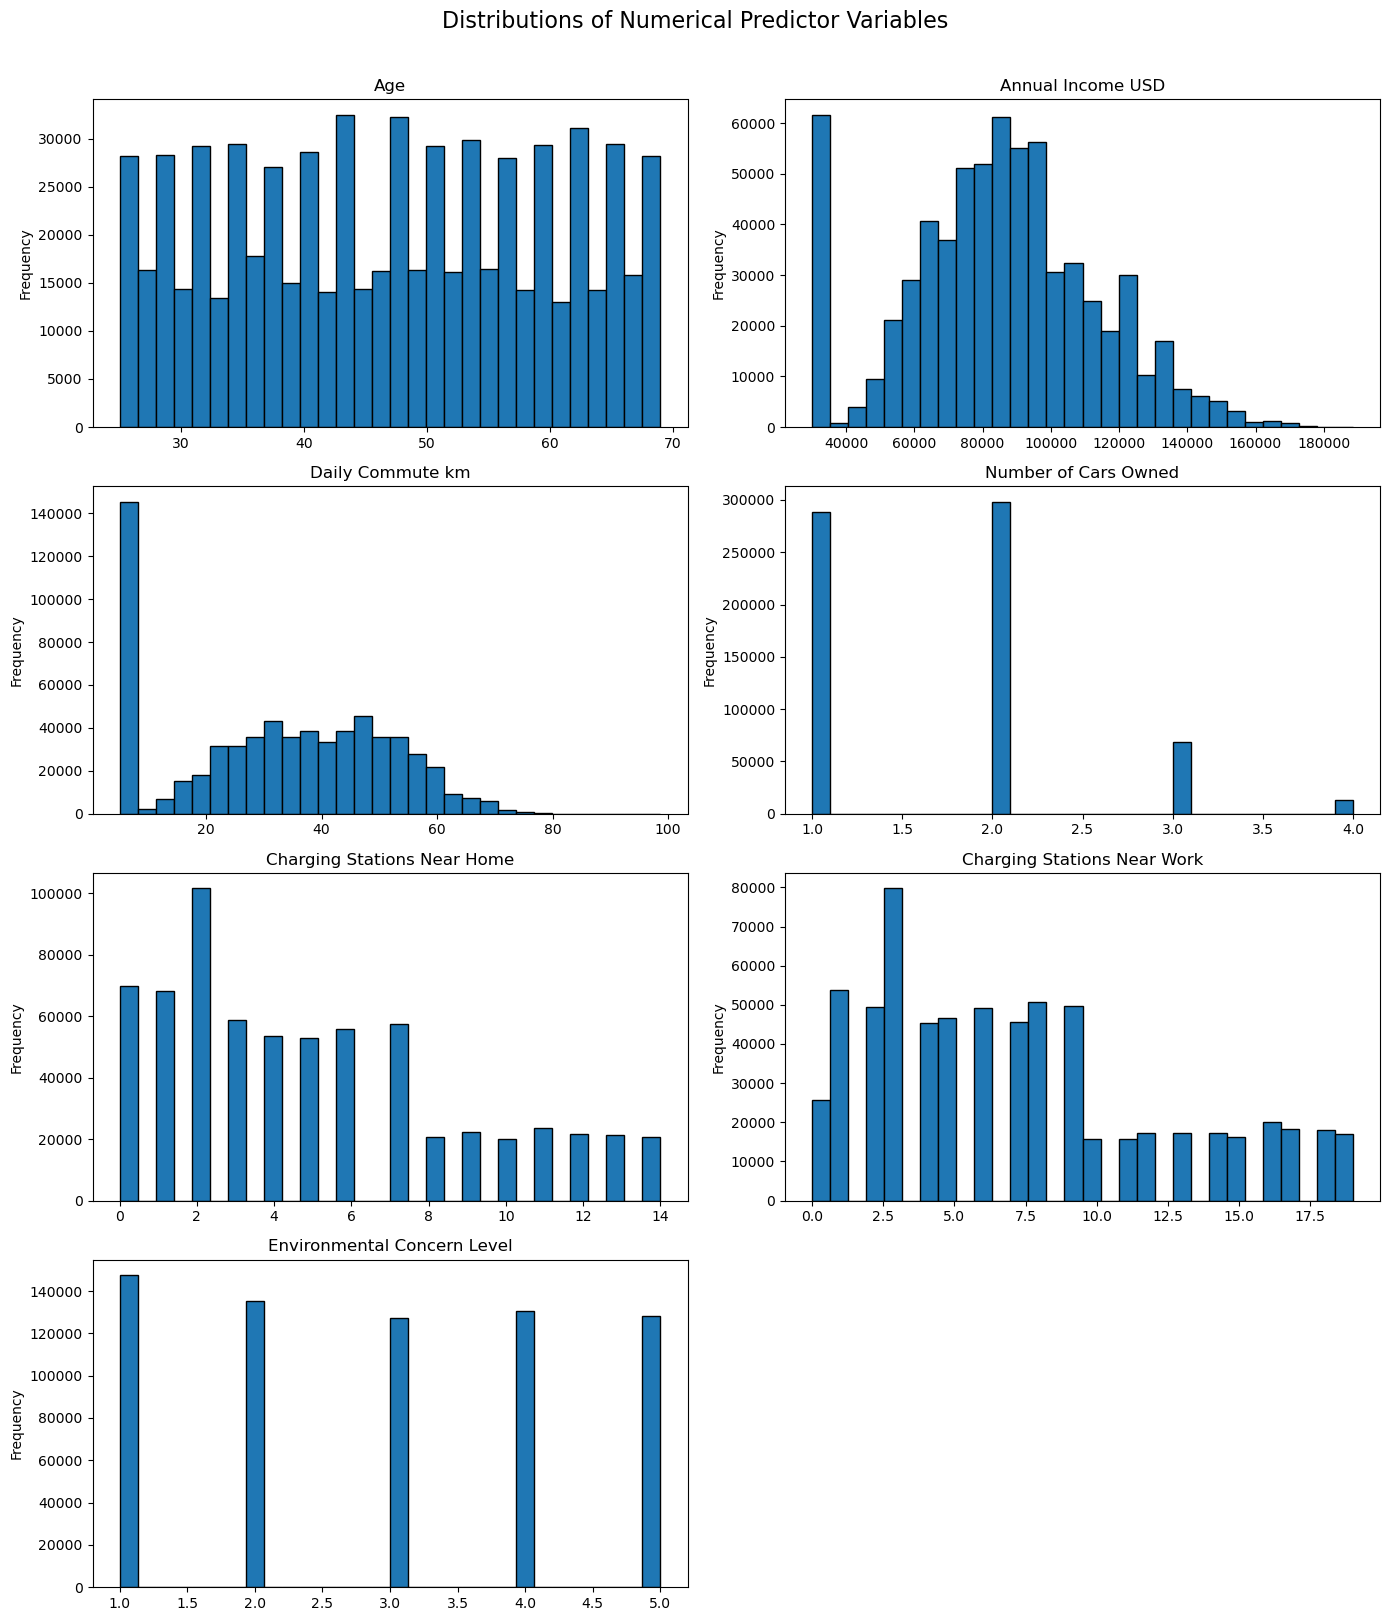

In [17]:
# Plot distributions of numerical predictors

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, column in enumerate(numeric_features):
    axes[i].hist(train[column], bins=30, edgecolor="black")
    axes[i].set_title(column.replace("_", " "))
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Frequency")

# Remove unused subplot
for j in range(len(numeric_features), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    "Distributions of Numerical Predictor Variables",
    fontsize=16,
    y=1.01
)

plt.tight_layout()
plt.show()

#### Categorical Feature Distributions

Bar charts are used to examine the frequency of observations within each categorical predictor. These distributions help identify dominant categories and potential imbalance within individual features.

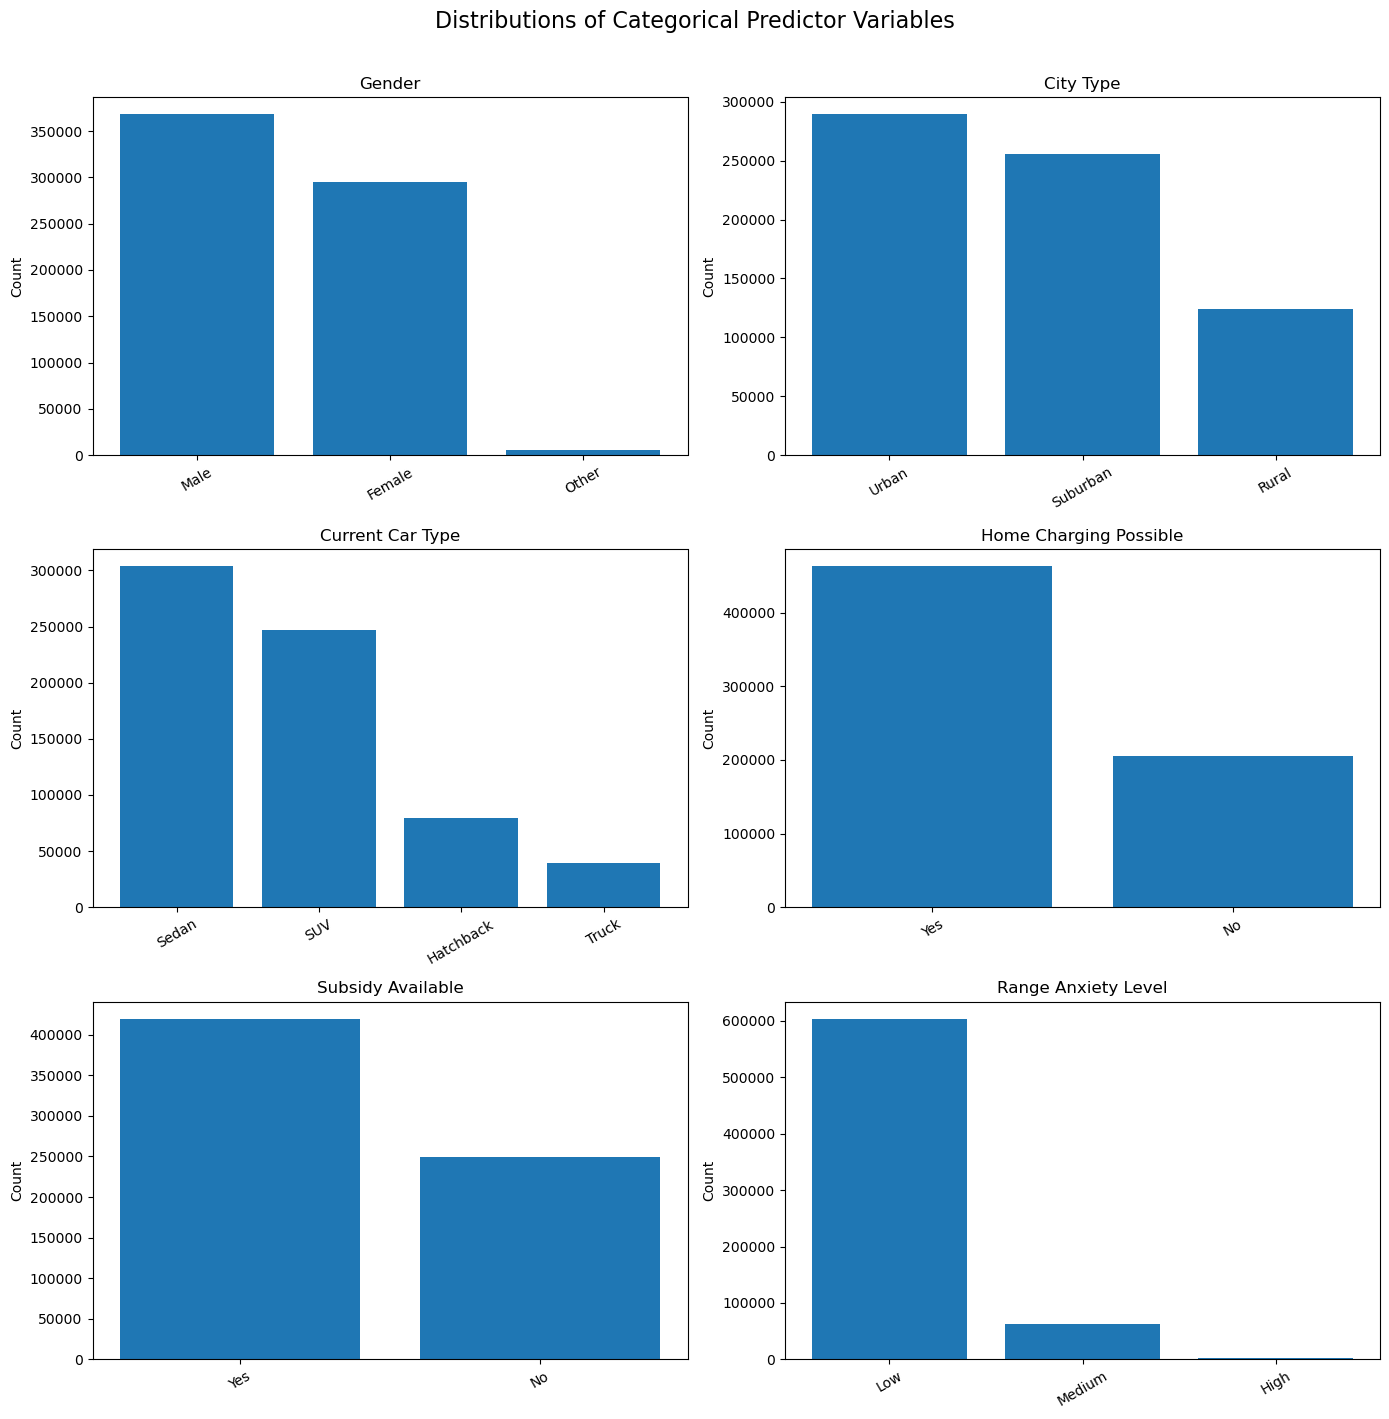

In [18]:
# Plot distributions of categorical predictors

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()

for i, column in enumerate(categorical_features):
    counts = train[column].value_counts()

    axes[i].bar(
        counts.index.astype(str),
        counts.values
    )

    axes[i].set_title(column.replace("_", " "))
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis="x", rotation=30)

plt.suptitle(
    "Distributions of Categorical Predictor Variables",
    fontsize=16,
    y=1.01
)

plt.tight_layout()
plt.show()

#### 5.1 Findings

The numerical predictors cover a broad range of demographic, transportation, charging-access, and environmental characteristics. Age ranges from 25 to 69 years, with a median of 47, while annual income ranges from $30,000 to $188,549 with a median of $84,880. Daily commute distance ranges from 5.0 to 98.7 kilometers, with a median of 33.6 kilometers.

Charging access varies considerably across the observations. The median number of charging stations near home is four, compared with six near work. Environmental concern is measured on a five-point scale and has a median value of three.

Several categorical variables show noticeable differences in group size. Urban and suburban observations are more common than rural observations, and sedans and SUVs account for most current vehicle types. Home charging is possible for a majority of the observations, and subsidies are available for more observations than they are unavailable. Range anxiety is particularly uneven, with most observations classified as Low and relatively few classified as High.

These distributions provide context for the subsequent analysis. Differences in category size and the distribution of numerical variables should be considered when comparing predictor characteristics with EV purchase interest.

### 5.2 Demographic Characteristics and EV Purchase Interest

Age, annual income, and gender are examined in relation to EV purchase interest. Comparing these demographic characteristics between individuals classified as `Yes` and `No` can help determine whether the variables may provide useful information for predicting EV purchase interest.

#### Age

Age is compared between the two EV purchase-interest groups using summary statistics and distributions.

In [19]:
# Compare age by EV purchase interest

age_summary = (
    train.groupby("Will_Buy_EV")["Age"]
    .agg(["count", "mean", "median", "std", "min", "max"])
)

age_summary.round(2)

,count,mean,median,std,min,max
Will_Buy_EV,,,,,,
No,551886,47.08,47.0,12.90,25,69
Yes,116779,46.83,47.0,12.77,25,69


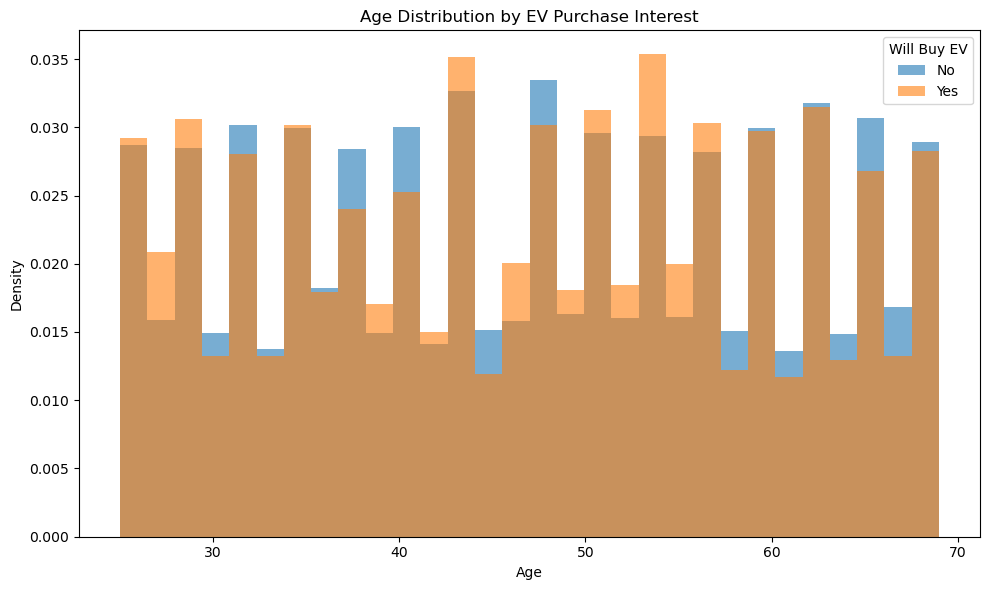

In [20]:
# Compare age distributions by EV purchase interest

plt.figure(figsize=(10, 6))

for outcome in ["No", "Yes"]:
    subset = train.loc[
        train["Will_Buy_EV"] == outcome,
        "Age"
    ]

    plt.hist(
        subset,
        bins=30,
        alpha=0.6,
        density=True,
        label=outcome
    )

plt.title("Age Distribution by EV Purchase Interest")
plt.xlabel("Age")
plt.ylabel("Density")
plt.legend(title="Will Buy EV")
plt.tight_layout()
plt.show()

#### Annual Income

Annual income is compared between the two target groups to determine whether income distributions differ according to EV purchase interest.

In [21]:
# Compare annual income by EV purchase interest

income_summary = (
    train.groupby("Will_Buy_EV")["Annual_Income_USD"]
    .agg(["count", "mean", "median", "std", "min", "max"])
)

income_summary.round(2)

,count,mean,median,std,min,max
Will_Buy_EV,,,,,,
No,551886,81794.59,82844.0,28237.16,30000.0,169972.0
Yes,116779,98827.30,96167.0,26300.68,30000.0,188549.0


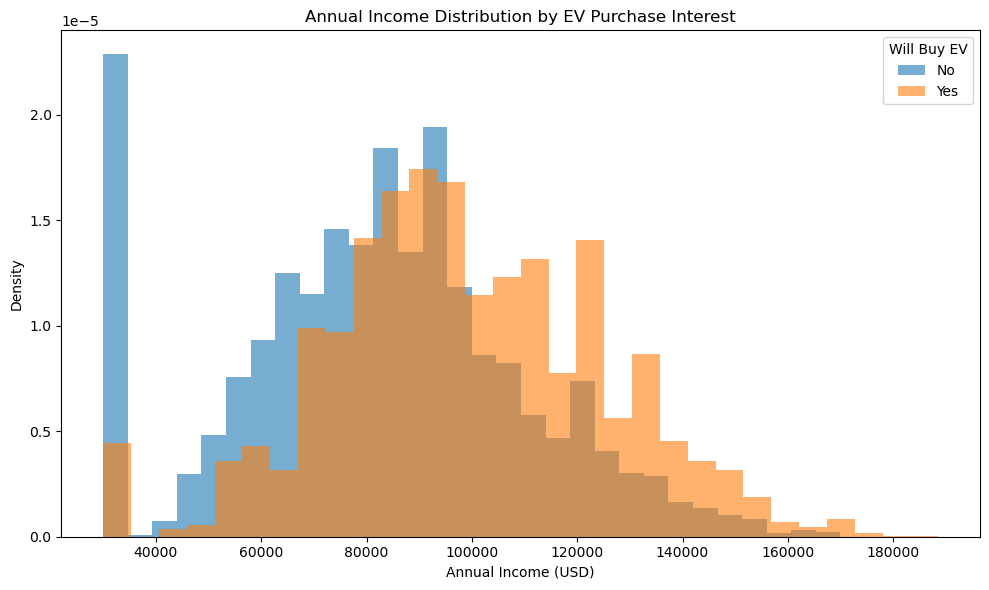

In [22]:
# Compare annual income distributions by EV purchase interest

plt.figure(figsize=(10, 6))

for outcome in ["No", "Yes"]:
    subset = train.loc[
        train["Will_Buy_EV"] == outcome,
        "Annual_Income_USD"
    ]

    plt.hist(
        subset,
        bins=30,
        alpha=0.6,
        density=True,
        label=outcome
    )

plt.title("Annual Income Distribution by EV Purchase Interest")
plt.xlabel("Annual Income (USD)")
plt.ylabel("Density")
plt.legend(title="Will Buy EV")
plt.tight_layout()
plt.show()

#### Gender

EV purchase interest is compared across gender categories using the percentage of observations within each category classified as `Yes`. Using within-group percentages accounts for differences in the number of observations represented by each gender category.

In [23]:
# Calculate EV purchase interest rate by gender

gender_purchase_rate = (
    train.groupby("Gender")["Will_Buy_EV"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

gender_purchase_rate.to_frame(
    "EV_Purchase_Interest_Percent"
).round(2)

,EV_Purchase_Interest_Percent
Gender,
Female,17.76
Other,17.37
Male,17.23


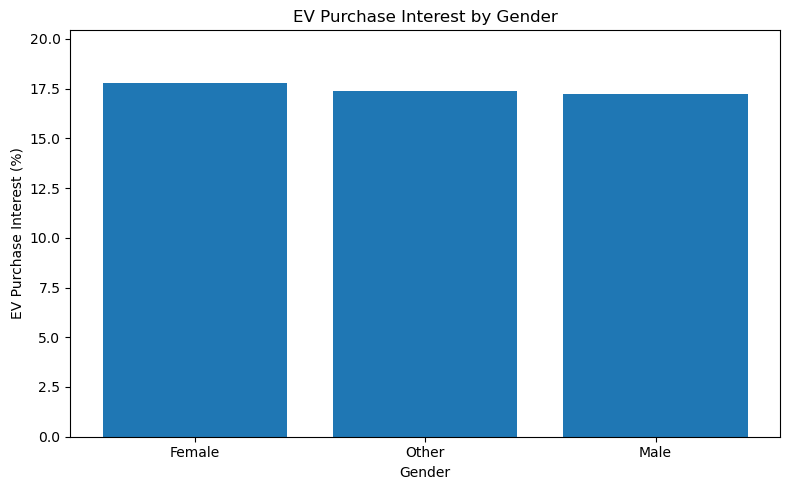

In [24]:
# Plot EV purchase interest rate by gender

plt.figure(figsize=(8, 5))

plt.bar(
    gender_purchase_rate.index.astype(str),
    gender_purchase_rate.values
)

plt.title("EV Purchase Interest by Gender")
plt.xlabel("Gender")
plt.ylabel("EV Purchase Interest (%)")

plt.ylim(
    0,
    gender_purchase_rate.max() * 1.15
)

plt.tight_layout()
plt.show()

In [25]:
# Summarize numerical demographic characteristics by target group

demographic_summary = (
    train.groupby("Will_Buy_EV")
    .agg(
        Average_Age=("Age", "mean"),
        Median_Age=("Age", "median"),
        Average_Income=("Annual_Income_USD", "mean"),
        Median_Income=("Annual_Income_USD", "median")
    )
)

demographic_summary.round(2)

,Average_Age,Median_Age,Average_Income,Median_Income
Will_Buy_EV,,,,
No,47.08,47.0,81794.59,82844.0
Yes,46.83,47.0,98827.30,96167.0


#### 5.2 Findings

Age distributions are very similar between the two EV purchase-interest groups. Individuals classified as `No` have an average age of 47.08 years, compared with 46.83 years for those classified as `Yes`, while both groups have a median age of 47. This suggests that age alone may provide limited separation between the two groups.

Annual income shows a more noticeable difference. Individuals classified as interested in purchasing an EV have an average annual income of approximately `$98,827` and a median income of `$96,167`. In comparison, individuals classified as `No` have an average income of approximately $81,795 and a median income of `$82,844`. The income distributions therefore suggest that annual income may provide useful information for predicting EV purchase interest.

Purchase-interest rates are similar across gender categories. Approximately 17.76% of females, 17.37% of individuals in the Other category, and 17.23% of males are classified as interested in purchasing an EV. These relatively small differences suggest that gender may have less predictive value on its own than annual income.

Overall, the demographic analysis identifies annual income as the most notable of the three demographic characteristics examined. These descriptive relationships will be evaluated further during model development rather than being interpreted as evidence of causation.

### 5.3 Transportation Characteristics and EV Purchase Interest

Daily commute distance, number of cars owned, and current vehicle type are examined in relation to EV purchase interest. These variables represent different aspects of an individual's current transportation needs and behavior and may provide useful information for predicting EV purchase interest.

#### Daily Commute Distance

Daily commute distance is compared between the two EV purchase-interest groups to determine whether commuting patterns differ between individuals classified as `Yes` and `No`.

In [26]:
# Compare daily commute distance by EV purchase interest

commute_summary = (
    train.groupby("Will_Buy_EV")["Daily_Commute_km"]
    .agg(["count", "mean", "median", "std", "min", "max"])
)

commute_summary.round(2)

,count,mean,median,std,min,max
Will_Buy_EV,,,,,,
No,551886,32.55,34.0,18.82,5.0,98.7
Yes,116779,30.29,31.7,18.18,5.0,82.9


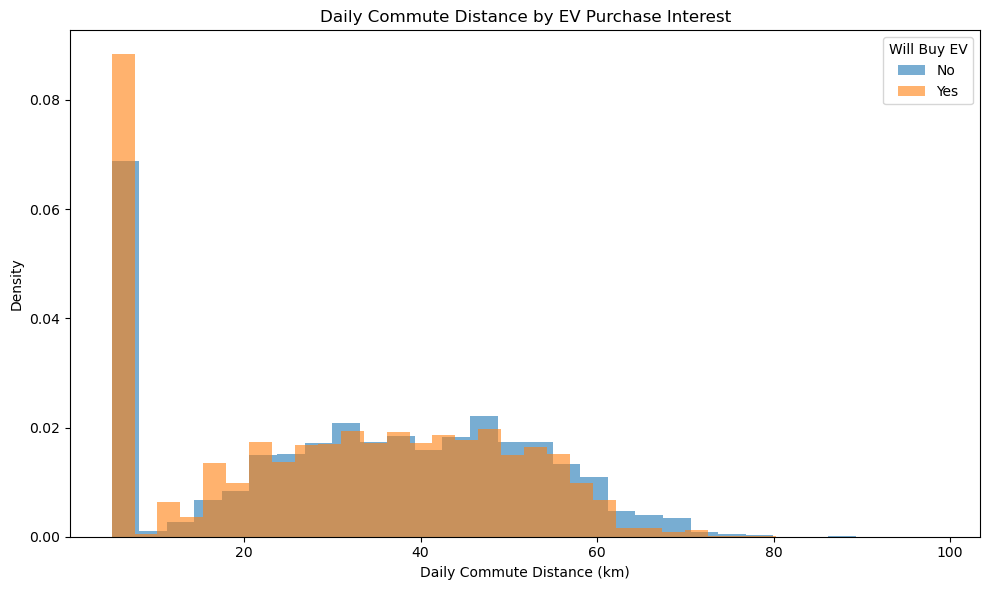

In [27]:
# Compare commute-distance distributions by EV purchase interest

plt.figure(figsize=(10, 6))

for outcome in ["No", "Yes"]:
    subset = train.loc[
        train["Will_Buy_EV"] == outcome,
        "Daily_Commute_km"
    ]

    plt.hist(
        subset,
        bins=30,
        alpha=0.6,
        density=True,
        label=outcome
    )

plt.title("Daily Commute Distance by EV Purchase Interest")
plt.xlabel("Daily Commute Distance (km)")
plt.ylabel("Density")
plt.legend(title="Will Buy EV")
plt.tight_layout()
plt.show()

#### Number of Cars Owned

The number of cars owned is compared across the two EV purchase-interest groups to determine whether existing vehicle ownership is associated with EV purchase interest.

In [28]:
# Compare number of cars owned by EV purchase interest

cars_summary = (
    train.groupby("Will_Buy_EV")["Number_of_Cars_Owned"]
    .agg(["count", "mean", "median", "std", "min", "max"])
)

cars_summary.round(2)

,count,mean,median,std,min,max
Will_Buy_EV,,,,,,
No,551886,1.71,2.0,0.73,1,4
Yes,116779,1.72,2.0,0.72,1,4


In [29]:
# Calculate EV purchase-interest rate by number of cars owned

cars_purchase_rate = (
    train.groupby("Number_of_Cars_Owned")["Will_Buy_EV"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

cars_purchase_rate.to_frame(
    "EV_Purchase_Interest_Percent"
).round(2)

,EV_Purchase_Interest_Percent
Number_of_Cars_Owned,
1,17.14
2,17.82
3,17.48
4,16.57


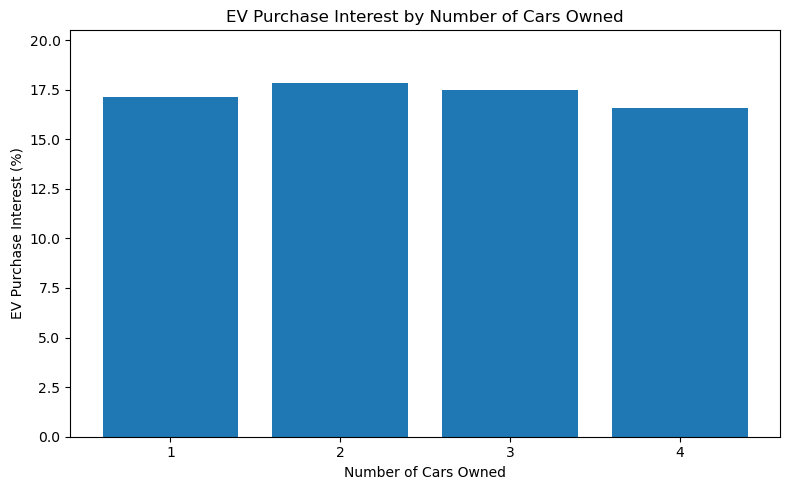

In [30]:
# Plot EV purchase-interest rate by number of cars owned

plt.figure(figsize=(8, 5))

plt.bar(
    cars_purchase_rate.index.astype(str),
    cars_purchase_rate.values
)

plt.title("EV Purchase Interest by Number of Cars Owned")
plt.xlabel("Number of Cars Owned")
plt.ylabel("EV Purchase Interest (%)")

plt.ylim(
    0,
    cars_purchase_rate.max() * 1.15
)

plt.tight_layout()
plt.show()

#### Current Car Type

EV purchase interest is compared across current vehicle types using the percentage of observations within each vehicle category classified as `Yes`. This comparison helps determine whether current vehicle choice is associated with EV purchase interest.

In [31]:
# Calculate EV purchase-interest rate by current car type

car_type_purchase_rate = (
    train.groupby("Current_Car_Type")["Will_Buy_EV"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

car_type_purchase_rate.to_frame(
    "EV_Purchase_Interest_Percent"
).round(2)

,EV_Purchase_Interest_Percent
Current_Car_Type,
SUV,18.10
Hatchback,17.43
Sedan,17.20
Truck,15.64


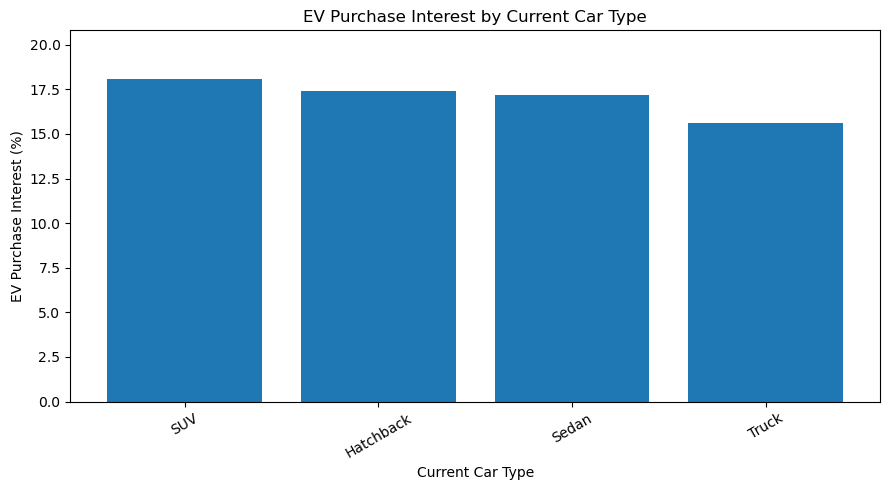

In [32]:
# Plot EV purchase-interest rate by current car type

plt.figure(figsize=(9, 5))

plt.bar(
    car_type_purchase_rate.index.astype(str),
    car_type_purchase_rate.values
)

plt.title("EV Purchase Interest by Current Car Type")
plt.xlabel("Current Car Type")
plt.ylabel("EV Purchase Interest (%)")
plt.xticks(rotation=30)

plt.ylim(
    0,
    car_type_purchase_rate.max() * 1.15
)

plt.tight_layout()
plt.show()

In [33]:
# Summarize numerical transportation characteristics by target group

transportation_summary = (
    train.groupby("Will_Buy_EV")
    .agg(
        Average_Commute_km=("Daily_Commute_km", "mean"),
        Median_Commute_km=("Daily_Commute_km", "median"),
        Average_Cars_Owned=("Number_of_Cars_Owned", "mean"),
        Median_Cars_Owned=("Number_of_Cars_Owned", "median")
    )
)

transportation_summary.round(2)

,Average_Commute_km,Median_Commute_km,Average_Cars_Owned,Median_Cars_Owned
Will_Buy_EV,,,,
No,32.55,34.0,1.71,2.0
Yes,30.29,31.7,1.72,2.0


#### 5.3 Findings

Daily commute distance shows a modest difference between the two EV purchase-interest groups. Individuals classified as `Yes` have an average daily commute of 30.29 km and a median of 31.7 km, compared with an average of 32.55 km and a median of 34.0 km for those classified as `No`. This suggests that individuals interested in purchasing an EV tend to have somewhat shorter commutes in this dataset.

The number of cars owned shows little difference between the two groups. Both groups have a median of two vehicles, while the average is 1.71 vehicles for individuals classified as `No` and 1.72 for those classified as `Yes`. EV purchase-interest rates are also relatively similar across ownership levels, ranging from 16.57% for individuals with four vehicles to 17.82% for those with two vehicles.

Current vehicle type shows somewhat greater variation. SUV owners have the highest EV purchase-interest rate at 18.10%, followed by hatchback owners at 17.43% and sedan owners at 17.20%. Truck owners have the lowest rate at 15.64%. Although these differences suggest that current vehicle type may provide some predictive information, they are relatively small and should be evaluated in combination with other features during model development.

Overall, the transportation characteristics show moderate differences in commute distance and current vehicle type but little difference in the number of cars owned. These relationships are descriptive and do not establish that the transportation characteristics cause differences in EV purchase interest.

### 5.4 Charging Access and Infrastructure

Access to charging infrastructure may influence interest in purchasing an electric vehicle. This section examines whether EV purchase interest differs according to the availability of home charging and the number of charging stations located near an individual's home and workplace.

#### Home Charging Availability

EV purchase interest is compared according to whether home charging is possible. Within-group percentages are used to account for differences in the number of observations in each category.

In [34]:
# Calculate EV purchase-interest rate by home charging availability

home_charging_rate = (
    train.groupby("Home_Charging_Possible")["Will_Buy_EV"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

home_charging_rate.to_frame(
    "EV_Purchase_Interest_Percent"
).round(2)

,EV_Purchase_Interest_Percent
Home_Charging_Possible,
Yes,19.58
No,12.71


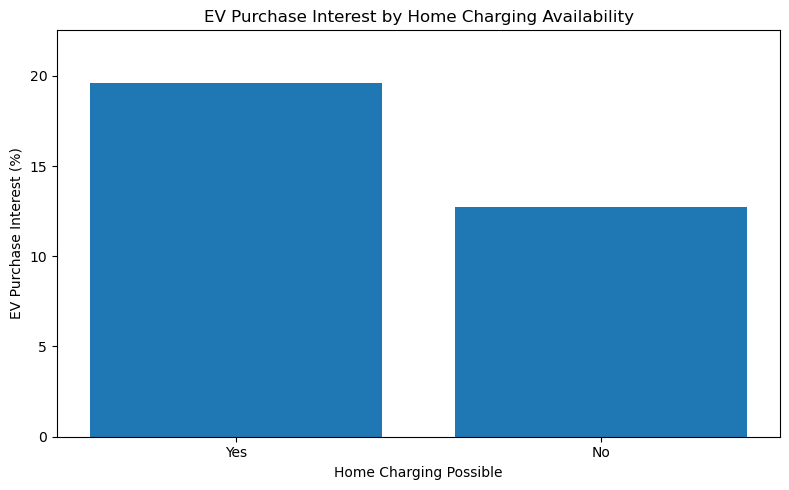

In [35]:
# Plot EV purchase-interest rate by home charging availability

plt.figure(figsize=(8, 5))

plt.bar(
    home_charging_rate.index.astype(str),
    home_charging_rate.values
)

plt.title("EV Purchase Interest by Home Charging Availability")
plt.xlabel("Home Charging Possible")
plt.ylabel("EV Purchase Interest (%)")

plt.ylim(
    0,
    home_charging_rate.max() * 1.15
)

plt.tight_layout()
plt.show()

#### Charging Stations Near Home

The number of charging stations near home is compared between the two EV purchase-interest groups to determine whether access to nearby charging infrastructure differs between individuals classified as `Yes` and `No`.

In [36]:
# Compare charging stations near home by EV purchase interest

home_station_summary = (
    train.groupby("Will_Buy_EV")["Charging_Stations_Near_Home"]
    .agg(["count", "mean", "median", "std", "min", "max"])
)

home_station_summary.round(2)

,count,mean,median,std,min,max
Will_Buy_EV,,,,,,
No,551886,4.99,4.0,3.92,0,14
Yes,116779,4.82,4.0,3.96,0,14


In [37]:
# Calculate EV purchase-interest rate by number of charging stations near home

home_station_rate = (
    train.groupby("Charging_Stations_Near_Home")["Will_Buy_EV"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

home_station_rate.to_frame(
    "EV_Purchase_Interest_Percent"
).round(2)

,EV_Purchase_Interest_Percent
Charging_Stations_Near_Home,
0,18.51
1,19.80
2,18.80
3,16.15
4,15.85
5,16.85
6,16.43
7,16.69
8,16.27


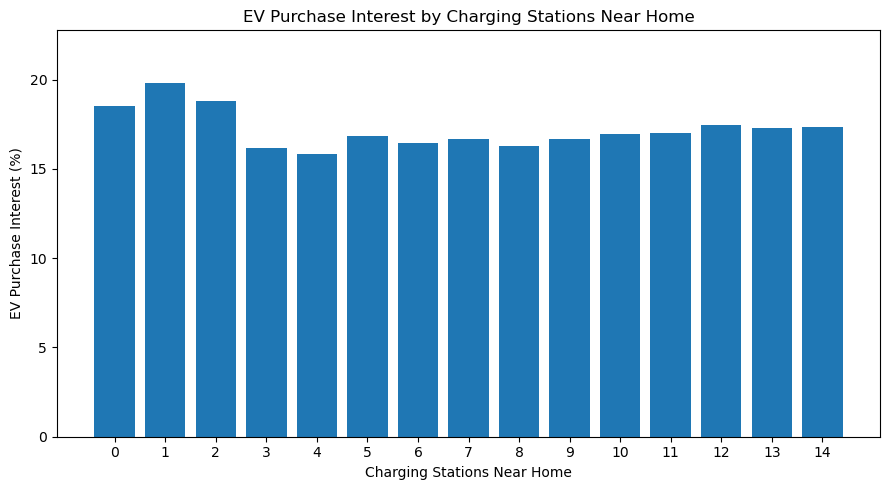

In [38]:
# Plot EV purchase-interest rate by charging stations near home

plt.figure(figsize=(9, 5))

plt.bar(
    home_station_rate.index.astype(str),
    home_station_rate.values
)

plt.title("EV Purchase Interest by Charging Stations Near Home")
plt.xlabel("Charging Stations Near Home")
plt.ylabel("EV Purchase Interest (%)")

plt.ylim(
    0,
    home_station_rate.max() * 1.15
)

plt.tight_layout()
plt.show()

#### Charging Stations Near Work

Charging availability near the workplace is examined to determine whether individuals with greater access to workplace-area charging infrastructure show different levels of EV purchase interest.

In [39]:
# Compare charging stations near work by EV purchase interest

work_station_summary = (
    train.groupby("Will_Buy_EV")["Charging_Stations_Near_Work"]
    .agg(["count", "mean", "median", "std", "min", "max"])
)

work_station_summary.round(2)

,count,mean,median,std,min,max
Will_Buy_EV,,,,,,
No,551886,7.21,6.0,5.19,0,19
Yes,116779,7.04,6.0,5.19,0,19


In [40]:
# Calculate EV purchase-interest rate by number of charging stations near work

work_station_rate = (
    train.groupby("Charging_Stations_Near_Work")["Will_Buy_EV"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

work_station_rate.to_frame(
    "EV_Purchase_Interest_Percent"
).round(2)

,EV_Purchase_Interest_Percent
Charging_Stations_Near_Work,
0,19.14
1,18.16
2,18.84
3,17.70
4,17.26
5,17.61
6,16.88
7,16.97
8,17.36


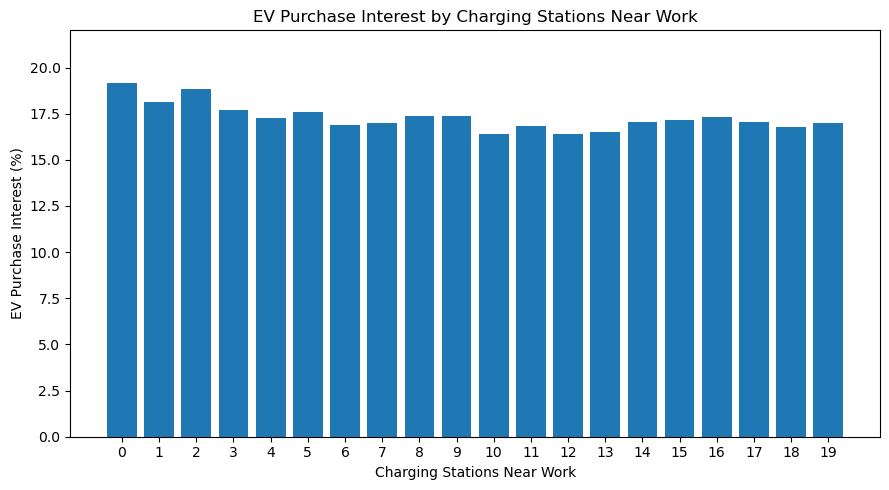

In [41]:
# Plot EV purchase-interest rate by charging stations near work

plt.figure(figsize=(9, 5))

plt.bar(
    work_station_rate.index.astype(str),
    work_station_rate.values
)

plt.title("EV Purchase Interest by Charging Stations Near Work")
plt.xlabel("Charging Stations Near Work")
plt.ylabel("EV Purchase Interest (%)")

plt.ylim(
    0,
    work_station_rate.max() * 1.15
)

plt.tight_layout()
plt.show()

In [42]:
# Summarize charging infrastructure by target group

charging_summary = (
    train.groupby("Will_Buy_EV")
    .agg(
        Average_Stations_Near_Home=(
            "Charging_Stations_Near_Home", "mean"
        ),
        Median_Stations_Near_Home=(
            "Charging_Stations_Near_Home", "median"
        ),
        Average_Stations_Near_Work=(
            "Charging_Stations_Near_Work", "mean"
        ),
        Median_Stations_Near_Work=(
            "Charging_Stations_Near_Work", "median"
        )
    )
)

charging_summary.round(2)

,Average_Stations_Near_Home,Median_Stations_Near_Home,Average_Stations_Near_Work,Median_Stations_Near_Work
Will_Buy_EV,,,,
No,4.99,4.0,7.21,6.0
Yes,4.82,4.0,7.04,6.0


#### 5.4 Findings

Home charging availability shows a noticeable difference in EV purchase interest. Among individuals for whom home charging is possible, 19.58% are classified as interested in purchasing an EV, compared with 12.71% among those without home charging access. This difference suggests that the availability of home charging may provide useful information for predicting EV purchase interest.

In contrast, the number of charging stations near home shows relatively little separation between the two target groups. Individuals classified as `Yes` have an average of 4.82 charging stations near home, compared with 4.99 for those classified as `No`, while both groups have a median of four stations. Purchase-interest rates also fluctuate across station counts rather than showing a consistent increase as the number of nearby stations increases.

A similar pattern appears for charging stations near work. Individuals classified as `Yes` have an average of 7.04 stations near work, compared with 7.21 for those classified as `No`, and both groups have a median of six. Purchase-interest rates vary across station counts but do not show a clear pattern of increasing interest as workplace charging availability increases.

Overall, home charging availability appears to distinguish the two purchase-interest groups more clearly than the number of charging stations near home or work. These descriptive relationships will be evaluated further during model development to determine how much predictive information each charging-related feature contributes when considered with the other variables.

### 5.5 Environmental Concerns, Range Anxiety, and Subsidies

Environmental attitudes, concerns about EV driving range, and the availability of purchase subsidies may be associated with interest in purchasing an electric vehicle. This section examines EV purchase interest across environmental concern levels, range anxiety categories, and subsidy availability.

#### Environmental Concern Level

Environmental concern is compared between the two EV purchase-interest groups. EV purchase-interest percentages are also calculated for each environmental concern level to determine whether interest changes across the five-point scale.

In [43]:
# Compare environmental concern by EV purchase interest

environment_summary = (
    train.groupby("Will_Buy_EV")["Environmental_Concern_Level"]
    .agg(["count", "mean", "median", "std", "min", "max"])
)

environment_summary.round(2)

,count,mean,median,std,min,max
Will_Buy_EV,,,,,,
No,551886,2.63,2.0,1.34,1.0,5.0
Yes,116779,4.38,5.0,0.84,1.0,5.0


In [44]:
# Calculate EV purchase-interest rate by environmental concern level

environment_purchase_rate = (
    train.groupby("Environmental_Concern_Level")["Will_Buy_EV"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

environment_purchase_rate.to_frame(
    "EV_Purchase_Interest_Percent"
).round(2)

,EV_Purchase_Interest_Percent
Environmental_Concern_Level,
1.0,0.57
2.0,2.14
3.0,11.09
4.0,24.88
5.0,51.83


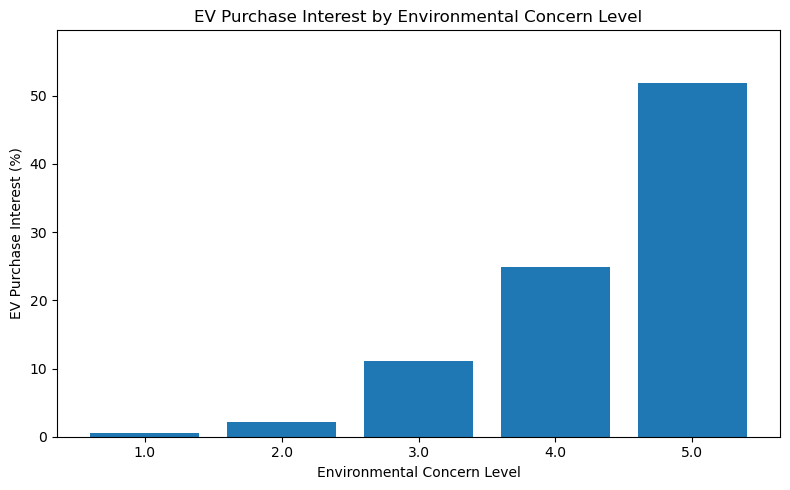

In [45]:
# Plot EV purchase-interest rate by environmental concern level

plt.figure(figsize=(8, 5))

plt.bar(
    environment_purchase_rate.index.astype(str),
    environment_purchase_rate.values
)

plt.title("EV Purchase Interest by Environmental Concern Level")
plt.xlabel("Environmental Concern Level")
plt.ylabel("EV Purchase Interest (%)")

plt.ylim(
    0,
    environment_purchase_rate.max() * 1.15
)

plt.tight_layout()
plt.show()

#### Range Anxiety Level

EV purchase interest is compared across range anxiety categories using the percentage of observations within each category classified as `Yes`. This analysis examines whether concerns about EV driving range are associated with differences in purchase interest.

In [46]:
# Calculate EV purchase-interest rate by range anxiety level

range_anxiety_rate = (
    train.groupby("Range_Anxiety_Level")["Will_Buy_EV"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

range_anxiety_rate.to_frame(
    "EV_Purchase_Interest_Percent"
).round(2)

,EV_Purchase_Interest_Percent
Range_Anxiety_Level,
High,0.14
Low,18.90
Medium,4.17


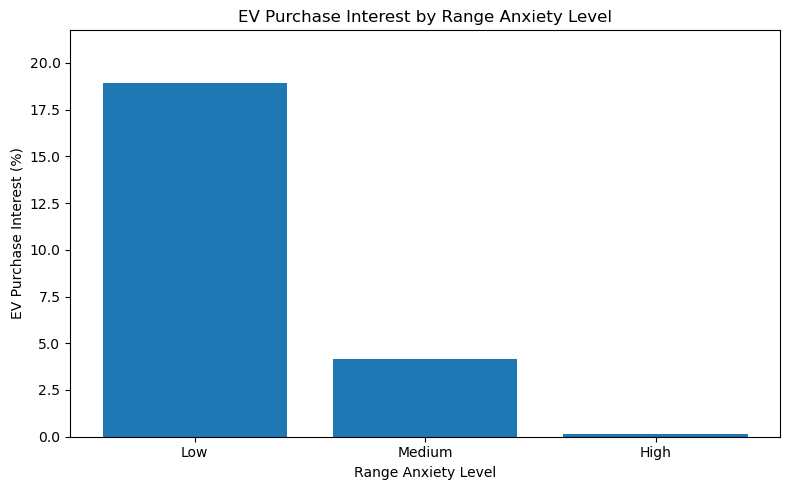

In [47]:
# Define logical order for range anxiety categories

range_order = ["Low", "Medium", "High"]

range_anxiety_plot = range_anxiety_rate.reindex(range_order)

plt.figure(figsize=(8, 5))

plt.bar(
    range_anxiety_plot.index,
    range_anxiety_plot.values
)

plt.title("EV Purchase Interest by Range Anxiety Level")
plt.xlabel("Range Anxiety Level")
plt.ylabel("EV Purchase Interest (%)")

plt.ylim(
    0,
    range_anxiety_plot.max() * 1.15
)

plt.tight_layout()
plt.show()

#### Subsidy Availability

EV purchase interest is compared according to whether a purchase subsidy is available. Within-group percentages are used so that differences in the number of observations with and without subsidy availability do not distort the comparison.

In [48]:
# Calculate EV purchase-interest rate by subsidy availability

subsidy_purchase_rate = (
    train.groupby("Subsidy_Available")["Will_Buy_EV"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

subsidy_purchase_rate.to_frame(
    "EV_Purchase_Interest_Percent"
).round(2)

,EV_Purchase_Interest_Percent
Subsidy_Available,
Yes,27.47
No,0.58


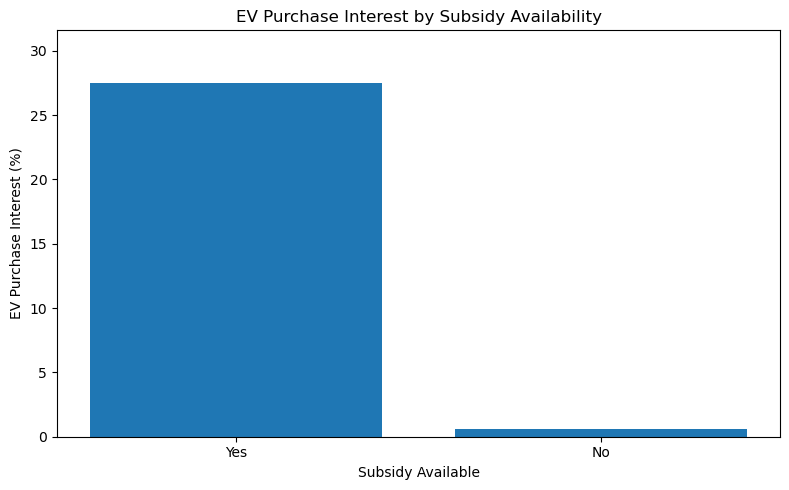

In [49]:
# Plot EV purchase-interest rate by subsidy availability

plt.figure(figsize=(8, 5))

plt.bar(
    subsidy_purchase_rate.index.astype(str),
    subsidy_purchase_rate.values
)

plt.title("EV Purchase Interest by Subsidy Availability")
plt.xlabel("Subsidy Available")
plt.ylabel("EV Purchase Interest (%)")

plt.ylim(
    0,
    subsidy_purchase_rate.max() * 1.15
)

plt.tight_layout()
plt.show()

In [50]:
# Summarize environmental concern by target group

behavioral_summary = (
    train.groupby("Will_Buy_EV")
    .agg(
        Average_Environmental_Concern=(
            "Environmental_Concern_Level", "mean"
        ),
        Median_Environmental_Concern=(
            "Environmental_Concern_Level", "median"
        )
    )
)

behavioral_summary.round(2)

,Average_Environmental_Concern,Median_Environmental_Concern
Will_Buy_EV,,
No,2.63,2.0
Yes,4.38,5.0


#### 5.5 Findings

Environmental concern shows a strong relationship with EV purchase interest. Individuals classified as `Yes` have an average environmental concern level of 4.38 and a median of 5, compared with an average of 2.63 and a median of 2 for those classified as `No`. EV purchase interest also increases consistently across the five environmental concern levels, from 0.57% at level 1 to 51.83% at level 5. This pattern suggests that environmental concern may provide substantial information for predicting EV purchase interest.

Range anxiety also shows a clear relationship with EV purchase interest. Among individuals with low range anxiety, 18.90% are classified as interested in purchasing an EV. This decreases to 4.17% for those with medium range anxiety and 0.14% for those with high range anxiety. The pattern indicates that higher levels of range anxiety are associated with substantially lower EV purchase interest in this dataset.

Subsidy availability produces another large difference between the groups. When a subsidy is available, 27.47% of individuals are classified as interested in purchasing an EV, compared with only 0.58% when a subsidy is not available. This suggests that subsidy availability may be an important predictor of EV purchase interest.

Overall, environmental concern, range anxiety, and subsidy availability show some of the clearest differences in EV purchase interest observed during the exploratory analysis. These relationships are descriptive rather than causal and will be evaluated further during model development to determine their predictive contribution when considered with the other features.

### 5.6 EDA Summary and Modeling Implications

The exploratory analysis identified substantial differences in the apparent relationship between individual predictors and EV purchase interest. Several variables showed clear descriptive separation between individuals classified as interested and not interested in purchasing an EV, while others showed relatively little difference when examined independently.

Environmental concern, range anxiety, and subsidy availability produced some of the strongest differences observed during the analysis. EV purchase interest increased substantially as environmental concern increased and decreased as range anxiety increased. Subsidy availability also showed a large difference in purchase interest between individuals with and without access to a subsidy. Home charging availability showed another noticeable relationship, with higher purchase interest among individuals for whom home charging is possible.

Annual income also differed between the two target groups, with higher average and median income among individuals classified as interested in purchasing an EV. Daily commute distance and current vehicle type showed smaller differences that may still contribute useful information when combined with other predictors.

Other variables, including age, gender, number of cars owned, and the number of charging stations near home or work, showed comparatively limited separation when examined individually. However, a weak univariate relationship does not necessarily mean that a variable lacks predictive value. A feature may become useful when considered in combination with other characteristics or through nonlinear relationships captured by some machine learning models.

The target variable is also imbalanced, with approximately 17.5% of the training observations classified as `Yes`. Model evaluation should therefore consider performance measures that are appropriate for imbalanced classification rather than relying on accuracy alone. ROC AUC will be used as the primary evaluation metric, consistent with the competition evaluation method.

Based on these findings, the modeling stage will retain the available predictor variables rather than selecting features solely from the exploratory analysis. Multiple classification approaches will be evaluated to determine whether linear, nonlinear, or interaction effects improve predictive performance. The EDA findings can then be compared with model-based measures of predictor importance to determine whether the relationships observed during exploratory analysis remain useful when the variables are considered together.

## 6. Data Preparation and Feature Engineering

The training data are prepared for machine learning by separating the predictor variables from the target, removing the identifier field from the predictors, and creating training and validation subsets. Numerical and categorical variables require different preprocessing steps, so a preprocessing pipeline is used to apply the appropriate transformations consistently.

Preprocessing is fit using only the training portion of the data to prevent information from the validation set from influencing model development. The same fitted transformations can later be applied to the competition test data when generating final predictions.

### 6.1 Define Features and Target

The target variable, `Will_Buy_EV`, is separated from the predictor variables. The `id` field is retained separately for the final Kaggle submission but is excluded from model training because it serves as an observation identifier rather than a meaningful predictor.

In [51]:
# Separate predictors, target, and test identifiers

X = train.drop(columns=["Will_Buy_EV", "id"])
y = train["Will_Buy_EV"]

X_test = test.drop(columns=["id"])
test_ids = test["id"]

print("Training predictors:", X.shape)
print("Training target:", y.shape)
print("Test predictors:", X_test.shape)
print("Test IDs:", test_ids.shape)

Training predictors: (668665, 13)
Training target: (668665,)
Test predictors: (286571, 13)
Test IDs: (286571,)


In [52]:
# Verify that training and test predictor columns match

print("Predictor columns match:", list(X.columns) == list(X_test.columns))
print("\nPredictor columns:")
print(X.columns.tolist())

Predictor columns match: True

Predictor columns:
['Age', 'Annual_Income_USD', 'Daily_Commute_km', 'Number_of_Cars_Owned', 'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work', 'Environmental_Concern_Level', 'Gender', 'City_Type', 'Current_Car_Type', 'Home_Charging_Possible', 'Subsidy_Available', 'Range_Anxiety_Level']


### 6.2 Training and Validation Split

The labeled data are divided into training and validation subsets so that model performance can be evaluated on observations that are not used for model fitting. An 80/20 split is used, with stratification based on the target variable to preserve approximately the same proportion of `Yes` and `No` observations in both subsets.

A fixed random state is used to make the split reproducible.

In [53]:
from sklearn.model_selection import train_test_split

In [54]:
# Create stratified training and validation subsets

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("y_train:", y_train.shape)
print("y_valid:", y_valid.shape)

X_train: (534932, 13)
X_valid: (133733, 13)
y_train: (534932,)
y_valid: (133733,)


In [55]:
# Compare target distribution across the full, training, and validation data

target_split_summary = pd.DataFrame({
    "Full Dataset (%)": y.value_counts(normalize=True) * 100,
    "Training (%)": y_train.value_counts(normalize=True) * 100,
    "Validation (%)": y_valid.value_counts(normalize=True) * 100
})

target_split_summary.round(2)

,Full Dataset (%),Training (%),Validation (%)
Will_Buy_EV,,,
No,82.54,82.54,82.54
Yes,17.46,17.46,17.46


### 6.3 Preprocessing Pipeline

The dataset contains both numerical and categorical predictors. Numerical variables are standardized, while categorical variables are converted to indicator variables using one-hot encoding.

These transformations are defined within a `ColumnTransformer` so that preprocessing can later be incorporated directly into each machine learning pipeline. Keeping preprocessing within the pipeline reduces the risk of data leakage and ensures that the same transformations are applied consistently to validation and test data.

In [56]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [57]:
# Identify numerical and categorical predictors

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features_model = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features_model)

Numerical features:
['Age', 'Annual_Income_USD', 'Daily_Commute_km', 'Number_of_Cars_Owned', 'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work', 'Environmental_Concern_Level']

Categorical features:
['Gender', 'City_Type', 'Current_Car_Type', 'Home_Charging_Possible', 'Subsidy_Available', 'Range_Anxiety_Level']


In [58]:
# Define preprocessing for numerical and categorical variables

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features_model
        )
    ]
)

preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


### 6.4 Verify the Preprocessing Configuration

Before model development, the preprocessing configuration is checked to confirm that all predictor variables are represented exactly once as either numerical or categorical features.

In [59]:
# Verify that all predictors are included in preprocessing

configured_features = (
    numerical_features +
    categorical_features_model
)

print("Number of predictors:", X.shape[1])
print("Number of configured predictors:", len(configured_features))

print(
    "All predictors included:",
    set(X.columns) == set(configured_features)
)

print(
    "Duplicate configured predictors:",
    len(configured_features) != len(set(configured_features))
)

Number of predictors: 13
Number of configured predictors: 13
All predictors included: True
Duplicate configured predictors: False


## 7. Model Development and Evaluation

Machine learning models are developed to predict EV purchase interest using the demographic, transportation, charging-access, environmental, and incentive-related predictors prepared in Section 6.

Model performance is evaluated primarily using the area under the receiver operating characteristic curve (ROC AUC). ROC AUC measures how well a model distinguishes between the two target classes across classification thresholds and is appropriate for this project because the target variable is imbalanced and the competition uses ROC AUC as its evaluation metric.

A simple baseline model is evaluated first, followed by logistic regression and a tree-based model. The models are trained using the training subset and evaluated using the same validation subset to provide a consistent comparison.

### 7.1 Evaluation Framework

Each model is evaluated on the validation data using ROC AUC calculated from the predicted probability of the `Yes` class. A common results table is used to compare model performance.

The dummy classifier provides a reference point for determining whether the machine learning models identify meaningful predictive patterns beyond a non-informative baseline.

In [60]:
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve

In [61]:
# Store validation results for model comparison

model_results = []

### 7.2 Dummy Classifier Baseline

A dummy classifier is used to establish a non-informative baseline. Because ROC AUC evaluates ranking ability rather than classification accuracy at a single threshold, a model without useful discriminatory information should produce an ROC AUC near 0.50.

The baseline provides a reference against which the predictive models can be evaluated.

In [62]:
# Create dummy-classifier pipeline

dummy_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DummyClassifier(
                strategy="prior",
                random_state=RANDOM_STATE
            )
        )
    ]
)

dummy_pipeline.fit(X_train, y_train)

dummy_probabilities = dummy_pipeline.predict_proba(X_valid)[:, 1]

dummy_auc = roc_auc_score(
    y_valid,
    dummy_probabilities
)

print(f"Dummy Classifier ROC AUC: {dummy_auc:.4f}")

Dummy Classifier ROC AUC: 0.5000


In [63]:
model_results.append({
    "Model": "Dummy Classifier",
    "ROC_AUC": dummy_auc
})

### 7.3 Logistic Regression

Logistic regression is used as the first predictive model. It provides an interpretable linear baseline and estimates EV purchase probability from the combined predictor variables.

The preprocessing pipeline standardizes numerical predictors and one-hot encodes categorical predictors before fitting the classifier. The model is evaluated using predicted probabilities on the validation data.

In [64]:
# Create logistic-regression pipeline

logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=RANDOM_STATE
            )
        )
    ]
)

logistic_pipeline.fit(X_train, y_train)

logistic_probabilities = logistic_pipeline.predict_proba(
    X_valid
)[:, 1]

logistic_auc = roc_auc_score(
    y_valid,
    logistic_probabilities
)

print(f"Logistic Regression ROC AUC: {logistic_auc:.4f}")

Logistic Regression ROC AUC: 0.9380


In [65]:
model_results.append({
    "Model": "Logistic Regression",
    "ROC_AUC": logistic_auc
})

### 7.4 Random Forest

A random forest classifier is used to evaluate whether nonlinear relationships and interactions among the predictors improve predictive performance. Random forests combine predictions from multiple decision trees and can capture relationships that may not be represented adequately by a linear model.

The initial model uses a fixed random state for reproducibility and class-weight adjustment to account for the imbalance in the target variable. Hyperparameter tuning is deferred until the initial models have been compared.

In [66]:
# Create initial random-forest pipeline

forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                max_depth=12,
                min_samples_leaf=5,
                class_weight="balanced",
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)

forest_pipeline.fit(X_train, y_train)

forest_probabilities = forest_pipeline.predict_proba(
    X_valid
)[:, 1]

forest_auc = roc_auc_score(
    y_valid,
    forest_probabilities
)

print(f"Random Forest ROC AUC: {forest_auc:.4f}")

Random Forest ROC AUC: 0.9376


In [67]:
model_results.append({
    "Model": "Random Forest",
    "ROC_AUC": forest_auc
})

### 7.5 Initial Model Comparison

The validation ROC AUC scores are compared to determine how much predictive improvement each model provides over the non-informative baseline. The comparison also indicates whether the nonlinear random forest provides an advantage over the linear logistic regression model.

In [68]:
# Compare initial model performance

model_comparison = (
    pd.DataFrame(model_results)
    .sort_values("ROC_AUC", ascending=False)
    .reset_index(drop=True)
)

model_comparison["ROC_AUC"] = (
    model_comparison["ROC_AUC"].round(4)
)

model_comparison

,Model,ROC_AUC
0,Logistic Regression,0.9380
1,Random Forest,0.9376
2,Dummy Classifier,0.5000


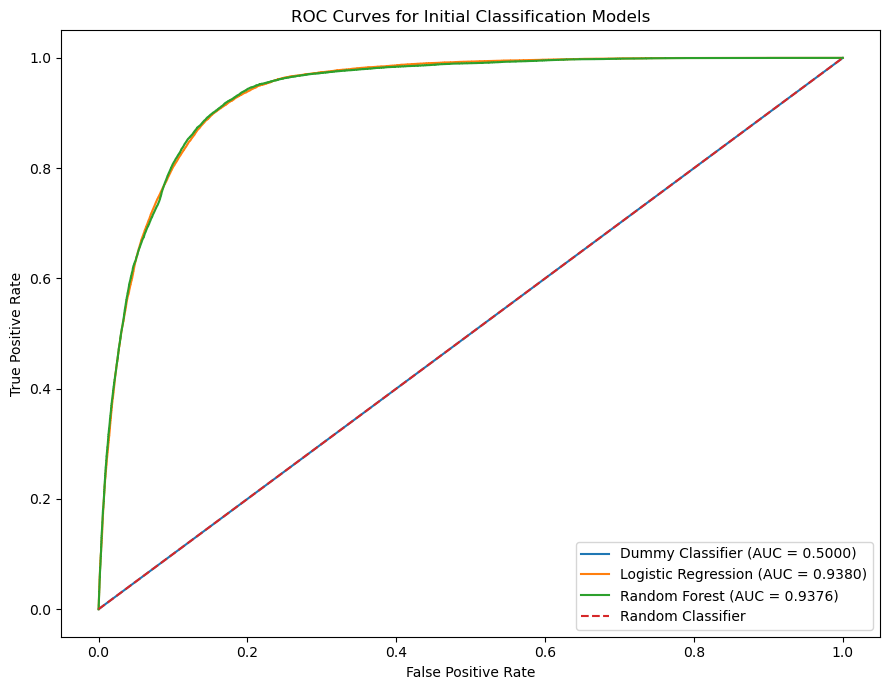

In [69]:
# Plot ROC curves for initial models

plt.figure(figsize=(9, 7))

for model_name, probabilities in [
    ("Dummy Classifier", dummy_probabilities),
    ("Logistic Regression", logistic_probabilities),
    ("Random Forest", forest_probabilities)
]:
    fpr, tpr, _ = roc_curve(
        y_valid,
        probabilities,
        pos_label="Yes"
    )

    auc_score = roc_auc_score(
        y_valid,
        probabilities
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} (AUC = {auc_score:.4f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curves for Initial Classification Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

#### 7.5 Findings

Both predictive models substantially outperform the dummy-classifier baseline. Logistic regression achieved a validation ROC AUC of 0.9380, while the random forest achieved 0.9376, compared with 0.5000 for the dummy classifier. These results indicate that the predictor variables contain substantial information for distinguishing between individuals classified as interested and not interested in purchasing an EV.

The initial random forest does not improve upon logistic regression. The two models differ by only 0.0004 ROC AUC, with logistic regression producing the slightly higher validation score. This suggests that the additional nonlinear structure represented by the initial random forest does not provide a meaningful performance advantage over the linear model under the current configuration.

Because logistic regression provides comparable or slightly better validation performance with a simpler and more interpretable model, it provides a strong benchmark for subsequent model development. Additional model evaluation will determine whether tuning or alternative modeling approaches can produce a meaningful improvement in ROC AUC.

### 7.6 Logistic Regression Interpretation

Because logistic regression produced the highest validation ROC AUC among the initial models, its coefficients are examined to better understand how the predictors contribute to the model's predictions.

Positive coefficients are associated with higher predicted probability of EV purchase interest, while negative coefficients are associated with lower predicted probability, holding the other model inputs constant. The magnitude of a coefficient reflects its influence on the model's log-odds scale; however, coefficients should be interpreted as model associations rather than causal effects.

In [70]:
# Retrieve transformed feature names from the fitted logistic pipeline

fitted_preprocessor = logistic_pipeline.named_steps["preprocessor"]

feature_names = fitted_preprocessor.get_feature_names_out()

logistic_coefficients = (
    logistic_pipeline
    .named_steps["classifier"]
    .coef_[0]
)

coefficient_table = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": logistic_coefficients
})

coefficient_table["Absolute_Coefficient"] = (
    coefficient_table["Coefficient"].abs()
)

coefficient_table = (
    coefficient_table
    .sort_values(
        "Absolute_Coefficient",
        ascending=False
    )
    .reset_index(drop=True)
)

coefficient_table

,Feature,Coefficient,Absolute_Coefficient
0,cat__Subsidy_Available_No,-3.167611,3.167611
1,cat__Range_Anxiety_Level_High,-2.394374,2.394374
2,num__Environmental_Concern_Level,1.874921,1.874921
3,cat__Subsidy_Available_Yes,1.380813,1.380813
4,cat__Range_Anxiety_Level_Low,1.119206,1.119206
5,cat__Home_Charging_Possible_No,-1.007979,1.007979
6,cat__Home_Charging_Possible_Yes,-0.778819,0.778819
7,num__Annual_Income_USD,0.727617,0.727617
8,cat__Gender_Male,-0.668084,0.668084
9,cat__Gender_Female,-0.646940,0.646940


In [71]:
# Display the strongest logistic-regression coefficients

top_coefficients = coefficient_table.head(15).copy()

top_coefficients[
    ["Feature", "Coefficient", "Absolute_Coefficient"]
].round(4)

,Feature,Coefficient,Absolute_Coefficient
0,cat__Subsidy_Available_No,-3.1676,3.1676
1,cat__Range_Anxiety_Level_High,-2.3944,2.3944
2,num__Environmental_Concern_Level,1.8749,1.8749
3,cat__Subsidy_Available_Yes,1.3808,1.3808
4,cat__Range_Anxiety_Level_Low,1.1192,1.1192
5,cat__Home_Charging_Possible_No,-1.0080,1.0080
6,cat__Home_Charging_Possible_Yes,-0.7788,0.7788
7,num__Annual_Income_USD,0.7276,0.7276
8,cat__Gender_Male,-0.6681,0.6681
9,cat__Gender_Female,-0.6469,0.6469


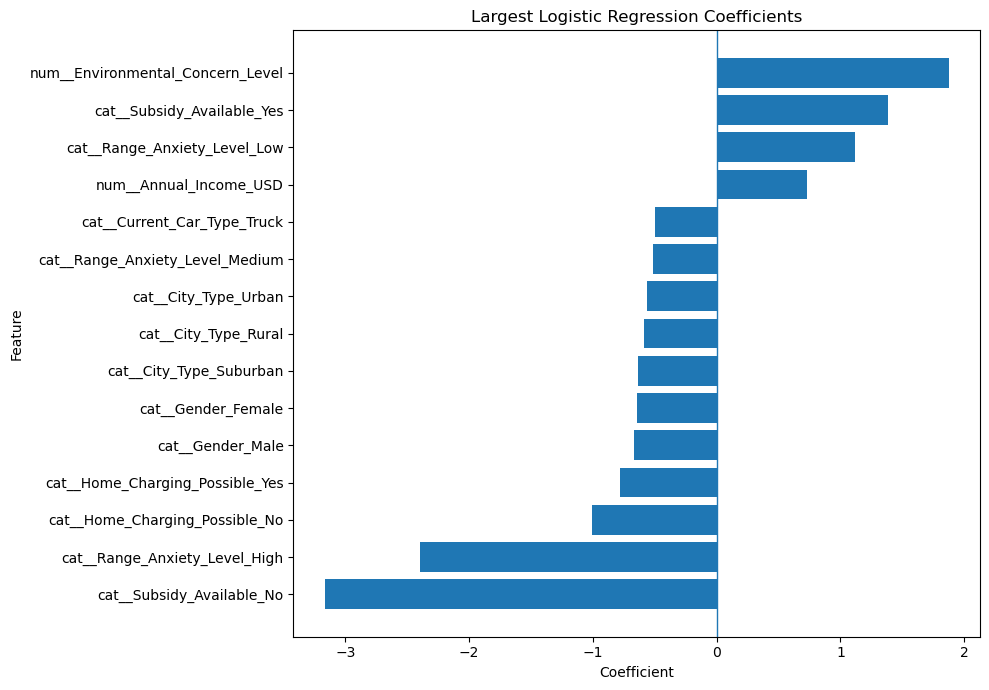

In [72]:
# Plot the strongest logistic-regression coefficients

plot_coefficients = (
    top_coefficients
    .sort_values("Coefficient")
)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_coefficients["Feature"],
    plot_coefficients["Coefficient"]
)

plt.axvline(
    x=0,
    linewidth=1
)

plt.title("Largest Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

#### 7.6 Findings

The logistic regression coefficients generally reinforce several relationships identified during exploratory analysis. Subsidy availability, range anxiety, environmental concern, home charging availability, and annual income appear among the variables associated with larger coefficient magnitudes.

Environmental concern has a relatively large positive coefficient, while high range anxiety has a large negative coefficient. Annual income also has a positive coefficient. These patterns are consistent with the descriptive relationships observed during EDA.

The subsidy indicators have particularly large coefficient magnitudes, further supporting the strong difference in EV purchase interest observed between individuals with and without subsidy availability. Home charging availability also contributes to the model, although interpretation of individual categorical coefficients requires caution because all categories were retained during one-hot encoding.

Overall, the coefficient analysis indicates that several of the relationships identified during EDA remain informative when the predictors are considered together. The coefficients represent associations within the fitted logistic regression model and should not be interpreted as causal effects.

### 7.7 Gradient Boosting Model

A histogram-based gradient boosting classifier is evaluated as an additional nonlinear modeling approach. Gradient boosting builds a sequence of decision trees in which each stage attempts to improve upon the errors of the preceding stages.

The histogram-based implementation is designed to train efficiently on larger datasets and can capture nonlinear relationships and interactions among predictors. Its validation performance is compared with logistic regression and random forest using the same ROC AUC metric.

In [73]:
from sklearn.ensemble import HistGradientBoostingClassifier

In [74]:
# Create preprocessing configuration for histogram gradient boosting

boosting_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features_model
        )
    ]
)

In [75]:
# Create histogram gradient-boosting pipeline

boosting_pipeline = Pipeline(
    steps=[
        ("preprocessor", boosting_preprocessor),
        (
            "classifier",
            HistGradientBoostingClassifier(
                learning_rate=0.1,
                max_iter=200,
                max_leaf_nodes=31,
                l2_regularization=1.0,
                random_state=RANDOM_STATE
            )
        )
    ]
)

boosting_pipeline.fit(
    X_train,
    y_train
)

boosting_probabilities = boosting_pipeline.predict_proba(
    X_valid
)[:, 1]

boosting_auc = roc_auc_score(
    y_valid,
    boosting_probabilities
)

print(
    f"Histogram Gradient Boosting ROC AUC: "
    f"{boosting_auc:.4f}"
)

Histogram Gradient Boosting ROC AUC: 0.9414


In [76]:
model_results.append({
    "Model": "Histogram Gradient Boosting",
    "ROC_AUC": boosting_auc
})

model_comparison = (
    pd.DataFrame(model_results)
    .drop_duplicates(
        subset="Model",
        keep="last"
    )
    .sort_values(
        "ROC_AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

model_comparison["ROC_AUC"] = (
    model_comparison["ROC_AUC"].round(4)
)

model_comparison

,Model,ROC_AUC
0,Histogram Gradient Boosting,0.9414
1,Logistic Regression,0.9380
2,Random Forest,0.9376
3,Dummy Classifier,0.5000


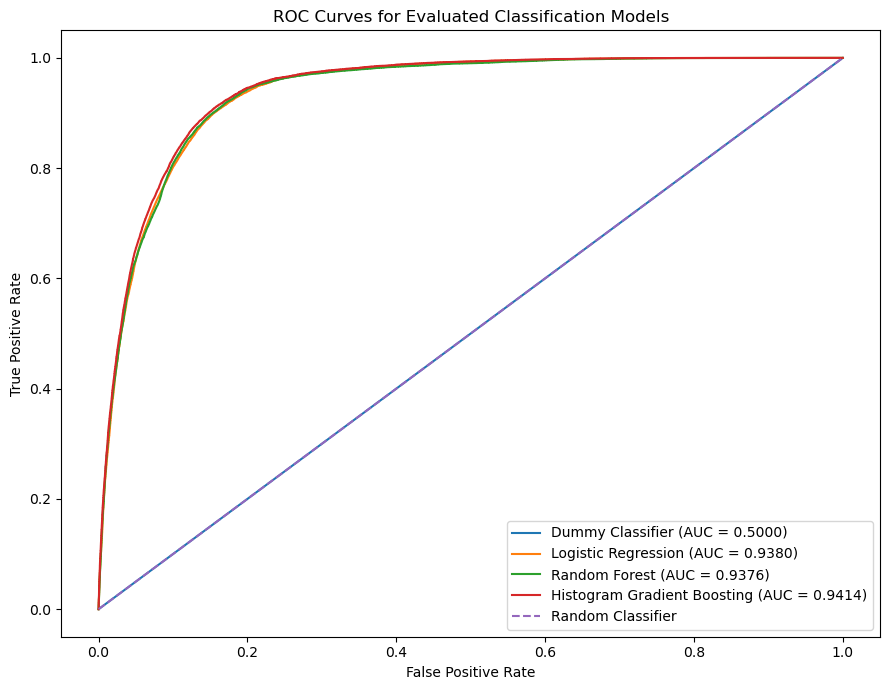

In [77]:
# Compare ROC curves for all evaluated models

plt.figure(figsize=(9, 7))

model_probabilities = [
    ("Dummy Classifier", dummy_probabilities),
    ("Logistic Regression", logistic_probabilities),
    ("Random Forest", forest_probabilities),
    ("Histogram Gradient Boosting", boosting_probabilities)
]

for model_name, probabilities in model_probabilities:
    fpr, tpr, _ = roc_curve(
        y_valid,
        probabilities,
        pos_label="Yes"
    )

    auc_score = roc_auc_score(
        y_valid,
        probabilities
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} (AUC = {auc_score:.4f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curves for Evaluated Classification Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

#### 7.7 Findings

Histogram gradient boosting achieved a validation ROC AUC of 0.9414, compared with 0.9380 for logistic regression and 0.9376 for random forest. All three predictive models substantially outperform the dummy-classifier baseline of 0.5000.

The gradient boosting model improves upon logistic regression by 0.0034 ROC AUC and random forest by 0.0038. Although the improvement is modest, it indicates that nonlinear relationships and interactions among the predictors provide additional predictive information beyond that captured by the initial logistic regression model.

Histogram gradient boosting therefore provides the strongest validation performance among the models evaluated so far. Before selecting a final model, limited hyperparameter tuning can be used to determine whether its performance can be improved further without unnecessarily increasing model complexity.

### 7.8 Histogram Gradient Boosting Tuning

Because histogram gradient boosting produced the highest initial validation ROC AUC, a limited set of model configurations is evaluated to determine whether changes to learning rate, tree complexity, and regularization improve performance.

The tuning process is intentionally constrained because of the large size of the training dataset. Each configuration is evaluated using the same validation set and ROC AUC metric used for the initial model comparison.

In [78]:
# Define a limited set of gradient-boosting configurations

boosting_configs = [
    {
        "Name": "Initial",
        "learning_rate": 0.10,
        "max_iter": 200,
        "max_leaf_nodes": 31,
        "l2_regularization": 1.0
    },
    {
        "Name": "Lower Learning Rate",
        "learning_rate": 0.05,
        "max_iter": 300,
        "max_leaf_nodes": 31,
        "l2_regularization": 1.0
    },
    {
        "Name": "Fewer Leaf Nodes",
        "learning_rate": 0.10,
        "max_iter": 200,
        "max_leaf_nodes": 15,
        "l2_regularization": 1.0
    },
    {
        "Name": "More Regularization",
        "learning_rate": 0.10,
        "max_iter": 200,
        "max_leaf_nodes": 31,
        "l2_regularization": 5.0
    }
]

In [79]:
# Fit boosting preprocessing using training data only

X_train_boost = boosting_preprocessor.fit_transform(X_train)

X_valid_boost = boosting_preprocessor.transform(X_valid)

print("Processed training shape:", X_train_boost.shape)
print("Processed validation shape:", X_valid_boost.shape)

Processed training shape: (534932, 24)
Processed validation shape: (133733, 24)


In [80]:
# Evaluate gradient-boosting configurations

boosting_tuning_results = []

for config in boosting_configs:

    model = HistGradientBoostingClassifier(
        learning_rate=config["learning_rate"],
        max_iter=config["max_iter"],
        max_leaf_nodes=config["max_leaf_nodes"],
        l2_regularization=config["l2_regularization"],
        random_state=RANDOM_STATE
    )

    model.fit(
        X_train_boost,
        y_train
    )

    probabilities = model.predict_proba(
        X_valid_boost
    )[:, 1]

    auc = roc_auc_score(
        y_valid,
        probabilities
    )

    boosting_tuning_results.append({
        "Configuration": config["Name"],
        "Learning_Rate": config["learning_rate"],
        "Max_Iterations": config["max_iter"],
        "Max_Leaf_Nodes": config["max_leaf_nodes"],
        "L2_Regularization": config["l2_regularization"],
        "ROC_AUC": auc
    })

    print(
        f"{config['Name']}: "
        f"ROC AUC = {auc:.4f}"
    )

Initial: ROC AUC = 0.9414
Lower Learning Rate: ROC AUC = 0.9413
Fewer Leaf Nodes: ROC AUC = 0.9414
More Regularization: ROC AUC = 0.9414


In [81]:
# Compare gradient-boosting configurations

boosting_tuning_table = (
    pd.DataFrame(boosting_tuning_results)
    .sort_values(
        "ROC_AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

boosting_tuning_table["ROC_AUC"] = (
    boosting_tuning_table["ROC_AUC"].round(4)
)

boosting_tuning_table

,Configuration,Learning_Rate,Max_Iterations,Max_Leaf_Nodes,L2_Regularization,ROC_AUC
0,Fewer Leaf Nodes,0.10,200,15,1.0,0.9414
1,Initial,0.10,200,31,1.0,0.9414
2,More Regularization,0.10,200,31,5.0,0.9414
3,Lower Learning Rate,0.05,300,31,1.0,0.9413


In [82]:
# Display tuning results with additional precision

boosting_tuning_precision = pd.DataFrame(
    boosting_tuning_results
).sort_values(
    "ROC_AUC",
    ascending=False
)

boosting_tuning_precision[
    ["Configuration", "ROC_AUC"]
].style.format({
    "ROC_AUC": "{:.6f}"
})

,Configuration,ROC_AUC
2,Fewer Leaf Nodes,0.941398
0,Initial,0.941396
3,More Regularization,0.941378
1,Lower Learning Rate,0.941344


#### 7.8 Findings

Limited hyperparameter tuning did not produce a meaningful improvement over the initial histogram gradient boosting model. The initial configuration, the model with fewer leaf nodes, and the model with greater L2 regularization all achieved a validation ROC AUC of approximately 0.9414 when rounded to four decimal places. Reducing the learning rate while increasing the number of iterations produced a slightly lower ROC AUC of 0.9413.

These results indicate that model performance is relatively stable across the configurations evaluated. Increasing regularization did not improve validation performance, and reducing the number of leaf nodes achieved performance comparable to the initial model while using a less complex tree structure.

Because the tuning results do not demonstrate a meaningful performance improvement, additional extensive tuning is not warranted at this stage. The histogram gradient boosting approach remains the strongest modeling method evaluated, with validation performance of approximately 0.9414 ROC AUC.

### 7.9 Final Model Selection

The model comparison and limited tuning results support the selection of histogram gradient boosting for the final model. The initial histogram gradient boosting model achieved a validation ROC AUC of approximately 0.9414, outperforming logistic regression at 0.9380 and random forest at 0.9376.

Hyperparameter tuning did not produce a meaningful improvement in validation performance. The configuration using 15 maximum leaf nodes achieved a ROC AUC of 0.941398, compared with 0.941396 for the initial 31-leaf configuration. Although this difference is negligible, the 15-leaf configuration provides equivalent predictive performance with lower tree complexity.

The final model will therefore use histogram gradient boosting with a learning rate of 0.10, 200 maximum iterations, 15 maximum leaf nodes, and L2 regularization of 1.0. The selected configuration will be retrained using the complete labeled training dataset before generating predicted probabilities for the competition test data.

## 8. Final Model and Kaggle Submission

After model selection, the chosen histogram gradient boosting configuration is retrained using the complete labeled training dataset. The preprocessing transformations are fit using all available training observations and then applied to the competition test data.

The final model generates predicted probabilities for EV purchase interest rather than class labels because the competition evaluates submissions using ROC AUC. These probabilities are combined with the test observation identifiers to create the submission file.

### 8.1 Prepare Full Training and Test Data

The preprocessing configuration is refit using the complete training dataset. The fitted transformations are then applied to the competition test data so that both datasets have the same model-ready feature representation.

In [83]:
# Fit preprocessing using the complete training dataset

X_full_boost = boosting_preprocessor.fit_transform(X)

X_test_boost = boosting_preprocessor.transform(X_test)

print("Processed full training shape:", X_full_boost.shape)
print("Processed test shape:", X_test_boost.shape)

Processed full training shape: (668665, 24)
Processed test shape: (286571, 24)


### 8.2 Train the Final Model

The selected histogram gradient boosting configuration is trained using all available labeled observations. Using the complete training dataset allows the final competition model to learn from observations that were previously reserved for validation.

In [84]:
# Train the selected model using the complete training dataset

final_model = HistGradientBoostingClassifier(
    learning_rate=0.10,
    max_iter=200,
    max_leaf_nodes=15,
    l2_regularization=1.0,
    random_state=RANDOM_STATE
)

final_model.fit(
    X_full_boost,
    y
)

print("Final model training complete.")

Final model training complete.


### 8.3 Generate Test Predictions

The final model is used to estimate the probability that each observation in the competition test dataset belongs to the `Yes` class. Probabilities are used rather than binary classifications because ROC AUC evaluates the ranking of predicted probabilities.

In [85]:
# Generate predicted probabilities for the competition test data

test_probabilities = final_model.predict_proba(
    X_test_boost
)[:, 1]

print("Number of predictions:", len(test_probabilities))
print(
    "Probability range:",
    f"{test_probabilities.min():.6f}",
    "to",
    f"{test_probabilities.max():.6f}"
)

Number of predictions: 286571
Probability range: 0.000038 to 0.965677


### 8.4 Verify the Required Submission Structure

Before creating the competition submission, the sample submission file is examined to confirm the required column names and number of observations. This prevents assumptions about the submission format and ensures that the model output is aligned with the competition requirements.

In [86]:
# Verify the required Kaggle submission structure

print(sample_submission.head())

print("\nSubmission columns:")
print(sample_submission.columns.tolist())

print("\nExpected rows:", len(sample_submission))
print("Test predictions:", len(test_probabilities))

       id  Will_Buy_EV
0  668665     0.174645
1  668666     0.174645
2  668667     0.174645
3  668668     0.174645
4  668669     0.174645

Submission columns:
['id', 'Will_Buy_EV']

Expected rows: 286571
Test predictions: 286571


### 8.5 Create and Validate the Submission File

The predicted probabilities are combined with the test observation identifiers using the same column structure provided in the competition sample submission file. Before saving the submission, the resulting dataset is checked for the expected number of rows, missing values, duplicate identifiers, and probability values outside the valid range of 0 to 1.

In [87]:
# Create the Kaggle submission

submission = sample_submission.copy()

submission["id"] = test_ids.values
submission["Will_Buy_EV"] = test_probabilities

submission.head()

,id,Will_Buy_EV
0,668665,0.010840
1,668666,0.020137
2,668667,0.006674
3,668668,0.003649
4,668669,0.019013


In [88]:
# Validate the submission file

print("Submission shape:", submission.shape)

print(
    "Columns match sample submission:",
    list(submission.columns) == list(sample_submission.columns)
)

print(
    "IDs match test data:",
    submission["id"].equals(test_ids.reset_index(drop=True))
)

print(
    "Duplicate IDs:",
    submission["id"].duplicated().sum()
)

print(
    "Missing values:",
    submission.isna().sum().sum()
)

print(
    "Probabilities within [0, 1]:",
    submission["Will_Buy_EV"].between(0, 1).all()
)

print(
    "Probability range:",
    f"{submission['Will_Buy_EV'].min():.6f}",
    "to",
    f"{submission['Will_Buy_EV'].max():.6f}"
)

Submission shape: (286571, 2)
Columns match sample submission: True
IDs match test data: True
Duplicate IDs: 0
Missing values: 0
Probabilities within [0, 1]: True
Probability range: 0.000038 to 0.965677


### 8.6 Save the Competition Submission

After validation, the submission is saved as a CSV file without an additional index column. The resulting file contains one row for each competition test observation and the model's predicted probability of EV purchase interest.

In [89]:
# Save the Kaggle submission file

submission.to_csv(
    "../data/submission.csv",
    index=False
)

print("Submission file saved successfully.")

Submission file saved successfully.


In [90]:
# Verify the saved submission file

submission_check = pd.read_csv("../data/submission.csv")

print("Saved submission shape:", submission_check.shape)

print(
    "Saved columns match:",
    list(submission_check.columns) == list(sample_submission.columns)
)

print(
    "Saved shape matches submission:",
    submission_check.shape == submission.shape
)

print(
    "Saved IDs match:",
    submission_check["id"].equals(
        submission["id"].reset_index(drop=True)
    )
)

print(
    "Saved probabilities match:",
    np.allclose(
        submission_check["Will_Buy_EV"],
        submission["Will_Buy_EV"]
    )
)

print(
    "Missing values:",
    submission_check.isna().sum().sum()
)

submission_check.head()

Saved submission shape: (286571, 2)
Saved columns match: True
Saved shape matches submission: True
Saved IDs match: True
Saved probabilities match: True
Missing values: 0


,id,Will_Buy_EV
0,668665,0.010840
1,668666,0.020137
2,668667,0.006674
3,668668,0.003649
4,668669,0.019013


## 9. Results and Conclusion

The final histogram gradient boosting model achieved a local validation ROC AUC of 0.941398. When the model was retrained using the complete training dataset and applied to the Kaggle competition test data, the resulting submission received a public leaderboard ROC AUC of 0.94118.

The difference between the local validation and public leaderboard scores was only 0.000218. The close agreement between these results indicates that the validation approach provided a reliable estimate of performance on unseen data and that the final model generalized well to the competition test set.

### 9.1 Key Findings

The exploratory analysis and modeling results identified several variables that were particularly useful for understanding and predicting EV purchase interest. Environmental concern showed one of the clearest relationships with the target, with EV purchase interest increasing substantially at higher levels of environmental concern. Range anxiety showed the opposite pattern, with purchase interest decreasing as range anxiety increased.

Subsidy availability and home charging access also showed substantial differences in EV purchase interest. Individuals with an available subsidy or the ability to charge at home had higher observed purchase interest than individuals without these characteristics. Annual income also provided useful separation between the target groups, with higher average and median income among individuals classified as interested in purchasing an EV.

Other variables, including age, gender, number of vehicles owned, and the number of charging stations near home or work, showed comparatively limited differences when examined individually. However, these variables were retained during modeling because predictors with weak individual relationships may still contribute information when considered with other variables.

The modeling results were consistent with many of the patterns identified during exploratory analysis. Logistic regression achieved a validation ROC AUC of 0.9380, while random forest achieved 0.9376. Histogram gradient boosting produced the strongest validation result at approximately 0.9414, demonstrating a modest improvement over the linear model and supporting its selection for the final competition submission.

### 9.2 Model Performance

The final histogram gradient boosting model used a learning rate of 0.10, 200 maximum iterations, 15 maximum leaf nodes, and L2 regularization of 1.0. Limited hyperparameter tuning showed very little variation in validation performance across the configurations evaluated, suggesting that the model was relatively stable within the tested parameter range.

The selected model achieved a validation ROC AUC of 0.941398. After retraining on the complete training dataset, the model received a Kaggle public leaderboard ROC AUC of 0.94118. The difference of 0.000218 between the two scores was small, indicating that the validation result closely approximated performance on the competition test data.

The Kaggle leaderboard result provides an external evaluation of the final model on data that were not used during model development. The close agreement between the validation and leaderboard results provides additional support for the modeling and validation approach used in this analysis.

### 9.3 Limitations

Several limitations should be considered when interpreting the results. The analysis identifies statistical relationships that are useful for prediction but does not establish that any predictor causes an individual to purchase an electric vehicle. Variables such as environmental concern, subsidy availability, income, and charging access may also be related to other characteristics that are not represented in the dataset.

The analysis is also limited to the variables provided in the competition data. Other factors that could influence EV purchasing decisions, such as vehicle price, electricity rates, gasoline prices, specific vehicle availability, household characteristics, and previous EV experience, are not included.

The target variable is imbalanced, with approximately 17.5% of the training observations classified as interested in purchasing an EV. ROC AUC was therefore used as the primary evaluation metric rather than accuracy. While ROC AUC measures the model's ability to rank positive observations above negative observations, it does not identify a probability threshold for making individual purchase classifications.

Finally, the Kaggle public leaderboard score represents performance on the public portion of the competition test data. It should therefore be treated as an additional measure of model performance rather than a replacement for the validation process used during model development.

### 9.4 Conclusion

This project developed an end-to-end machine learning workflow for predicting electric vehicle purchase interest using demographic, financial, transportation, charging-access, and attitudinal characteristics. The analysis included data validation, exploratory analysis, preprocessing, baseline development, comparison of multiple classification approaches, limited hyperparameter tuning, final model training, and external evaluation through a Kaggle competition submission.

Environmental concern, range anxiety, subsidy availability, home charging access, and annual income emerged as some of the most informative characteristics during exploratory analysis and model interpretation. Histogram gradient boosting provided the strongest predictive performance among the models evaluated, achieving a local validation ROC AUC of 0.941398 and a Kaggle public leaderboard ROC AUC of 0.94118.

The close agreement between the validation and leaderboard results indicates that the validation approach provided a useful estimate of performance on unseen competition data. Overall, the project demonstrates how exploratory analysis, model comparison, validation, and external evaluation can be combined to develop and assess a reproducible classification model.